# FraudGuard ML: An Imbalance-Aware Credit Card Transaction Fraud Detection System

## Development Notebook

This notebook contains the technical development workflow for loading, inspecting,
preparing, modelling and evaluating the credit card transaction fraud dataset.

Target variable: `is_fraud`

- `0` = legitimate transaction
- `1` = fraudulent transaction

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [2]:
PROJECT_ROOT = Path("..")
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_FILE = RAW_DATA_DIR / "fraudTrain.csv"
TEST_FILE = RAW_DATA_DIR / "fraudTest.csv"

print("Training file:", TRAIN_FILE.resolve())
print("Testing file: ", TEST_FILE.resolve())

print("\nFile existence check:")
print("fraudTrain.csv exists:", TRAIN_FILE.exists())
print("fraudTest.csv exists: ", TEST_FILE.exists())

Training file: E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\data\raw\fraudTrain.csv
Testing file:  E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\data\raw\fraudTest.csv

File existence check:
fraudTrain.csv exists: True
fraudTest.csv exists:  True


In [3]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
print("Training shape:", train_df.shape)
print("Testing shape: ", test_df.shape)

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training shape: (1296675, 23)
Testing shape:  (555719, 23)

Training columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Testing columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [5]:
train_columns = set(train_df.columns)
test_columns = set(test_df.columns)

print("Same columns:", train_columns == test_columns)
print("Only in training:", train_columns - test_columns)
print("Only in testing:", test_columns - train_columns)

Same columns: True
Only in training: set()
Only in testing: set()


In [6]:
display(train_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [7]:
display(test_df.head())

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.8600,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.9864,-81.2007,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.8400,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.4505,-109.9604,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.2800,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.4958,-74.1961,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.0500,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.8124,-80.8831,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.1900,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.9591,-85.8847,0


In [8]:
print("Training data types:")
display(train_df.dtypes.to_frame(name="dtype"))

Training data types:


,dtype
Unnamed: 0,int64
trans_date_trans_time,str
cc_num,int64
merchant,str
category,str
amt,float64
first,str
last,str
gender,str
street,str


In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [10]:
def missing_value_summary(df):
    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    })

    return summary.sort_values(
        by=["missing_percent", "missing_count"],
        ascending=False
    )


print("Training missing values:")
train_missing = missing_value_summary(train_df)
display(train_missing[train_missing["missing_count"] > 0])

print("Testing missing values:")
test_missing = missing_value_summary(test_df)
display(test_missing[test_missing["missing_count"] > 0])

Training missing values:


,missing_count,missing_percent


Testing missing values:


,missing_count,missing_percent


In [11]:
train_exact_duplicates = train_df.duplicated().sum()
test_exact_duplicates = test_df.duplicated().sum()

print("Exact duplicate rows in training:", train_exact_duplicates)
print("Exact duplicate rows in testing: ", test_exact_duplicates)

Exact duplicate rows in training: 0
Exact duplicate rows in testing:  0


In [12]:
if "trans_num" in train_df.columns:
    print(
        "Duplicate trans_num values in training:",
        train_df["trans_num"].duplicated().sum()
    )

if "trans_num" in test_df.columns:
    print(
        "Duplicate trans_num values in testing:",
        test_df["trans_num"].duplicated().sum()
    )

Duplicate trans_num values in training: 0
Duplicate trans_num values in testing: 0


In [13]:
TARGET = "is_fraud"

train_target_counts = train_df[TARGET].value_counts().sort_index()
train_target_percent = (
    train_df[TARGET].value_counts(normalize=True).sort_index() * 100
)

train_target_summary = pd.DataFrame({
    "count": train_target_counts,
    "percentage": train_target_percent
})

print("Training target distribution:")
display(train_target_summary)

Training target distribution:


,count,percentage
is_fraud,,
0,1289169,99.4211
1,7506,0.5789


In [14]:
test_target_counts = test_df[TARGET].value_counts().sort_index()
test_target_percent = (
    test_df[TARGET].value_counts(normalize=True).sort_index() * 100
)

test_target_summary = pd.DataFrame({
    "count": test_target_counts,
    "percentage": test_target_percent
})

print("Testing target distribution:")
display(test_target_summary)

Testing target distribution:


,count,percentage
is_fraud,,
0,553574,99.6140
1,2145,0.3860


In [15]:
print(
    "Training fraud rate:",
    f"{train_df[TARGET].mean() * 100:.4f}%"
)

print(
    "Testing fraud rate:",
    f"{test_df[TARGET].mean() * 100:.4f}%"
)

Training fraud rate: 0.5789%
Testing fraud rate: 0.3860%


In [16]:
train_dates = pd.to_datetime(
    train_df["trans_date_trans_time"],
    errors="coerce"
)

test_dates = pd.to_datetime(
    test_df["trans_date_trans_time"],
    errors="coerce"
)

print("Training date range:")
print("Start:", train_dates.min())
print("End:  ", train_dates.max())

print("\nTesting date range:")
print("Start:", test_dates.min())
print("End:  ", test_dates.max())

print("\nInvalid training dates:", train_dates.isna().sum())
print("Invalid testing dates: ", test_dates.isna().sum())

Training date range:
Start: 2019-01-01 00:00:18
End:   2020-06-21 12:13:37

Testing date range:
Start: 2020-06-21 12:14:25
End:   2020-12-31 23:59:34

Invalid training dates: 0
Invalid testing dates:  0


## Dataset Partition Assessment

The supplied training and testing files are separated chronologically. Before defining
the experimental workflow, customer and merchant overlap between the datasets is
examined to understand whether the final test set contains known or unseen entities.

In [17]:
train_customers = set(train_df["cc_num"].unique())
test_customers = set(test_df["cc_num"].unique())

shared_customers = train_customers.intersection(test_customers)
test_only_customers = test_customers.difference(train_customers)

print("Unique customers in training:", len(train_customers))
print("Unique customers in testing: ", len(test_customers))
print("Customers present in both:    ", len(shared_customers))
print("Customers only in testing:    ", len(test_only_customers))

customer_overlap_percent = (
    len(shared_customers) / len(test_customers) * 100
)

print(
    "Test customer overlap:",
    f"{customer_overlap_percent:.2f}%"
)

Unique customers in training: 983
Unique customers in testing:  924
Customers present in both:     908
Customers only in testing:     16
Test customer overlap: 98.27%


In [18]:
train_merchants = set(train_df["merchant"].unique())
test_merchants = set(test_df["merchant"].unique())

shared_merchants = train_merchants.intersection(test_merchants)
test_only_merchants = test_merchants.difference(train_merchants)

print("Unique merchants in training:", len(train_merchants))
print("Unique merchants in testing: ", len(test_merchants))
print("Merchants present in both:    ", len(shared_merchants))
print("Merchants only in testing:    ", len(test_only_merchants))

merchant_overlap_percent = (
    len(shared_merchants) / len(test_merchants) * 100
)

print(
    "Test merchant overlap:",
    f"{merchant_overlap_percent:.2f}%"
)

Unique merchants in training: 693
Unique merchants in testing:  693
Merchants present in both:     693
Merchants only in testing:     0
Test merchant overlap: 100.00%


In [19]:
profile_columns = [
    "cc_num",
    "first",
    "last",
    "gender",
    "street",
    "city",
    "state",
    "zip",
    "lat",
    "long",
    "city_pop",
    "job",
    "dob"
]

train_profiles = train_df[profile_columns].drop_duplicates()
test_profiles = test_df[profile_columns].drop_duplicates()

print("Unique customer profiles in training:", train_profiles.shape[0])
print("Unique customer profiles in testing: ", test_profiles.shape[0])

Unique customer profiles in training: 983
Unique customer profiles in testing:  924


## Initial Data Cleaning and Type Conversion

Working copies of the original datasets are created so that the raw loaded data remains
unchanged. The exported CSV row index is removed, and date-related columns are converted
from text into datetime values for later feature engineering.

In [20]:
train_clean = train_df.copy()
test_clean = test_df.copy()

index_column = "Unnamed: 0"

if index_column in train_clean.columns:
    train_clean = train_clean.drop(columns=index_column)

if index_column in test_clean.columns:
    test_clean = test_clean.drop(columns=index_column)

print("Training shape after index removal:", train_clean.shape)
print("Testing shape after index removal: ", test_clean.shape)

Training shape after index removal: (1296675, 22)
Testing shape after index removal:  (555719, 22)


In [21]:
date_columns = [
    "trans_date_trans_time",
    "dob"
]

for column in date_columns:
    train_clean[column] = pd.to_datetime(
        train_clean[column],
        errors="coerce"
    )

    test_clean[column] = pd.to_datetime(
        test_clean[column],
        errors="coerce"
    )

print("Training date data types:")
display(train_clean[date_columns].dtypes.to_frame(name="dtype"))

print("Testing date data types:")
display(test_clean[date_columns].dtypes.to_frame(name="dtype"))

Training date data types:


,dtype
trans_date_trans_time,datetime64[us]
dob,datetime64[us]


Testing date data types:


,dtype
trans_date_trans_time,datetime64[us]
dob,datetime64[us]


In [22]:
date_validation = pd.DataFrame({
    "train_invalid_dates": train_clean[date_columns].isna().sum(),
    "test_invalid_dates": test_clean[date_columns].isna().sum()
})

display(date_validation)

,train_invalid_dates,test_invalid_dates
trans_date_trans_time,0,0
dob,0,0


In [23]:
print("Original training columns:", train_df.shape[1])
print("Clean training columns:   ", train_clean.shape[1])

print("\nUnnamed index in original data:",
      "Unnamed: 0" in train_df.columns)

print("Unnamed index in clean data:",
      "Unnamed: 0" in train_clean.columns)

Original training columns: 23
Clean training columns:    22

Unnamed index in original data: True
Unnamed index in clean data: False


## Feature Engineering

Meaningful numerical features are derived from transaction timestamps, customer dates
of birth, geographical coordinates and transaction amounts. The same transformations
are applied consistently to the development and final test datasets.

In [24]:
def engineer_features(df):
    engineered = df.copy()

    transaction_time = engineered["trans_date_trans_time"]
    date_of_birth = engineered["dob"]

    # Time-based features
    engineered["transaction_hour"] = transaction_time.dt.hour
    engineered["transaction_day_of_week"] = transaction_time.dt.dayofweek
    engineered["transaction_month"] = transaction_time.dt.month

    engineered["is_weekend"] = (
        engineered["transaction_day_of_week"] >= 5
    ).astype(int)

    # Customer age at the transaction date
    age_before_birthday = (
        (transaction_time.dt.month < date_of_birth.dt.month)
        |
        (
            (transaction_time.dt.month == date_of_birth.dt.month)
            &
            (transaction_time.dt.day < date_of_birth.dt.day)
        )
    )

    engineered["customer_age"] = (
        transaction_time.dt.year
        - date_of_birth.dt.year
        - age_before_birthday.astype(int)
    )

    # Haversine distance between customer and merchant coordinates
    customer_lat = np.radians(engineered["lat"])
    customer_long = np.radians(engineered["long"])
    merchant_lat = np.radians(engineered["merch_lat"])
    merchant_long = np.radians(engineered["merch_long"])

    latitude_difference = merchant_lat - customer_lat
    longitude_difference = merchant_long - customer_long

    haversine_value = (
        np.sin(latitude_difference / 2) ** 2
        +
        np.cos(customer_lat)
        * np.cos(merchant_lat)
        * np.sin(longitude_difference / 2) ** 2
    )

    earth_radius_km = 6371.0

    engineered["customer_merchant_distance_km"] = (
        2
        * earth_radius_km
        * np.arcsin(np.sqrt(haversine_value))
    )

    # Amount transformation
    engineered["log_transaction_amount"] = np.log1p(engineered["amt"])

    return engineered

In [25]:
train_features = engineer_features(train_clean)
test_features = engineer_features(test_clean)

new_time_features = [
    "transaction_hour",
    "transaction_day_of_week",
    "transaction_month",
    "is_weekend",
    "customer_age"
]

display(train_features[new_time_features].head())

,transaction_hour,transaction_day_of_week,transaction_month,is_weekend,customer_age
0,0,1,1,0,30
1,0,1,1,0,40
2,0,1,1,0,56
3,0,1,1,0,51
4,0,1,1,0,32


In [26]:
display(
    train_features[new_time_features]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
transaction_hour,"1,296,675.0000",12.8049,6.8178,0.0000,7.0000,14.0000,19.0000,23.0000
transaction_day_of_week,"1,296,675.0000",3.0706,2.1982,0.0000,1.0000,3.0000,5.0000,6.0000
transaction_month,"1,296,675.0000",6.1421,3.4177,1.0000,3.0000,6.0000,9.0000,12.0000
is_weekend,"1,296,675.0000",0.3482,0.4764,0.0000,0.0000,0.0000,1.0000,1.0000
customer_age,"1,296,675.0000",45.4969,17.3970,13.0000,32.0000,43.0000,57.0000,95.0000


In [27]:
print("Invalid engineered values in training:")
display(train_features[new_time_features].isna().sum())

print("Invalid engineered values in testing:")
display(test_features[new_time_features].isna().sum())

Invalid engineered values in training:


transaction_hour           0
transaction_day_of_week    0
transaction_month          0
is_weekend                 0
customer_age               0
dtype: int64

Invalid engineered values in testing:


transaction_hour           0
transaction_day_of_week    0
transaction_month          0
is_weekend                 0
customer_age               0
dtype: int64

### Geographical and Transaction Amount Features

Customer and merchant coordinates are used to calculate the approximate transaction
distance. The transaction amount is also log-transformed to reduce the effect of a
strong right-skew while preserving the original amount.

In [28]:
new_numeric_features = [
    "customer_merchant_distance_km",
    "log_transaction_amount"
]

display(train_features[new_numeric_features].head())

display(
    train_features[new_numeric_features]
    .describe()
    .T
)

,customer_merchant_distance_km,log_transaction_amount
0,78.5976,1.7867
1,30.2122,4.6843
2,108.2061,5.3987
3,95.6732,3.8286
4,77.5567,3.7603


,count,mean,std,min,25%,50%,75%,max
customer_merchant_distance_km,"1,296,675.0000",76.1147,29.1169,0.0223,55.3349,78.2318,98.5033,152.1172
log_transaction_amount,"1,296,675.0000",3.5335,1.2894,0.6931,2.3656,3.8820,4.4325,10.2733


In [29]:
print("Invalid new feature values in training:")
display(train_features[new_numeric_features].isna().sum())

print("Invalid new feature values in testing:")
display(test_features[new_numeric_features].isna().sum())

print(
    "Negative distances in training:",
    (train_features["customer_merchant_distance_km"] < 0).sum()
)

print(
    "Negative distances in testing:",
    (test_features["customer_merchant_distance_km"] < 0).sum()
)

Invalid new feature values in training:


customer_merchant_distance_km    0
log_transaction_amount           0
dtype: int64

Invalid new feature values in testing:


customer_merchant_distance_km    0
log_transaction_amount           0
dtype: int64

Negative distances in training: 0
Negative distances in testing: 0


## Categorical Cardinality Analysis

Categorical variables are inspected using only the development dataset. The number of
unique values in each column is examined to distinguish low-cardinality predictors from
high-cardinality identifiers and fields that may require alternative handling.

In [31]:
categorical_columns = train_features.select_dtypes(
    include=["object", "str", "category"]
).columns.tolist()

categorical_cardinality = pd.DataFrame({
    "column": categorical_columns,
    "unique_count": [
        train_features[column].nunique(dropna=False)
        for column in categorical_columns
    ],
    "unique_percentage": [
        train_features[column].nunique(dropna=False)
        / len(train_features)
        * 100
        for column in categorical_columns
    ]
})

categorical_cardinality = categorical_cardinality.sort_values(
    by="unique_count",
    ascending=False
).reset_index(drop=True)

print("Number of categorical columns:", len(categorical_columns))
display(categorical_cardinality)

Number of categorical columns: 10


,column,unique_count,unique_percentage
0,trans_num,1296675,100.0000
1,street,983,0.0758
2,city,894,0.0689
3,merchant,693,0.0534
4,job,494,0.0381
5,last,481,0.0371
6,first,352,0.0271
7,state,51,0.0039
8,category,14,0.0011
9,gender,2,0.0002


In [32]:
customer_static_columns = [
    "first",
    "last",
    "gender",
    "street",
    "city",
    "state",
    "zip",
    "job"
]

customer_field_consistency = pd.DataFrame({
    "column": customer_static_columns,
    "max_unique_values_per_customer": [
        train_features.groupby("cc_num")[column].nunique().max()
        for column in customer_static_columns
    ],
    "customers_with_multiple_values": [
        (
            train_features.groupby("cc_num")[column].nunique() > 1
        ).sum()
        for column in customer_static_columns
    ]
})

display(customer_field_consistency)

,column,max_unique_values_per_customer,customers_with_multiple_values
0,first,1,0
1,last,1,0
2,gender,1,0
3,street,1,0
4,city,1,0
5,state,1,0
6,zip,1,0
7,job,1,0


In [33]:
customer_profile_columns = [
    "first",
    "last",
    "gender",
    "street",
    "city",
    "state",
    "zip",
    "job"
]

customer_identification_analysis = []

for column in customer_profile_columns:
    customers_per_value = (
        train_features.groupby(column)["cc_num"]
        .nunique()
    )

    customer_identification_analysis.append({
        "column": column,
        "unique_values": train_features[column].nunique(),
        "values_used_by_one_customer": (customers_per_value == 1).sum(),
        "percentage_values_used_by_one_customer": (
            (customers_per_value == 1).mean() * 100
        ),
        "median_customers_per_value": customers_per_value.median(),
        "maximum_customers_per_value": customers_per_value.max()
    })

customer_identification_analysis = pd.DataFrame(
    customer_identification_analysis
).sort_values(
    by="percentage_values_used_by_one_customer",
    ascending=False
).reset_index(drop=True)

display(customer_identification_analysis)

,column,unique_values,values_used_by_one_customer,percentage_values_used_by_one_customer,median_customers_per_value,maximum_customers_per_value
0,street,983,983,100.0000,1.0000,1
1,zip,970,957,98.6598,1.0000,2
2,city,894,826,92.3937,1.0000,5
3,last,481,264,54.8857,1.0000,19
4,first,352,163,46.3068,2.0000,26
5,job,494,202,40.8907,2.0000,6
6,state,51,2,3.9216,17.0000,71
7,gender,2,0,0.0000,491.5000,497


In [34]:
numerical_columns = train_features.select_dtypes(
    include=["number"]
).columns.tolist()

numerical_summary = pd.DataFrame({
    "column": numerical_columns,
    "dtype": [
        train_features[column].dtype
        for column in numerical_columns
    ],
    "unique_count": [
        train_features[column].nunique(dropna=False)
        for column in numerical_columns
    ],
    "unique_percentage": [
        train_features[column].nunique(dropna=False)
        / len(train_features)
        * 100
        for column in numerical_columns
    ],
    "minimum": [
        train_features[column].min()
        for column in numerical_columns
    ],
    "maximum": [
        train_features[column].max()
        for column in numerical_columns
    ]
})

numerical_summary = numerical_summary.sort_values(
    by="unique_count",
    ascending=False
).reset_index(drop=True)

print("Number of numerical columns:", len(numerical_columns))
display(numerical_summary)

Number of numerical columns: 17


,column,dtype,unique_count,unique_percentage,minimum,maximum
0,customer_merchant_distance_km,float64,1296675,100.0000,0.0223,152.1172
1,merch_long,float64,1275745,98.3859,-166.6712,-66.9509
2,unix_time,int64,1274823,98.3148,"1,325,376,018.0000","1,371,816,817.0000"
3,merch_lat,float64,1247805,96.2311,19.0278,67.5103
4,log_transaction_amount,float64,52928,4.0818,0.6931,10.2733
5,amt,float64,52928,4.0818,1.0000,"28,948.9000"
6,cc_num,int64,983,0.0758,"60,416,207,185.0000","4,992,346,398,065,154,048.0000"
7,zip,int64,970,0.0748,"1,257.0000","99,783.0000"
8,long,float64,969,0.0747,-165.6723,-67.9503
9,lat,float64,968,0.0747,20.0271,66.6933


In [35]:
numerical_features_for_review = [
    "amt",
    "log_transaction_amount",
    "city_pop",
    "customer_age",
    "customer_merchant_distance_km",
    "transaction_hour",
    "transaction_day_of_week",
    "transaction_month",
    "is_weekend"
]

numerical_correlation = (
    train_features[numerical_features_for_review]
    .corr(method="spearman")
    .round(4)
)

display(numerical_correlation)

,amt,log_transaction_amount,city_pop,customer_age,customer_merchant_distance_km,transaction_hour,transaction_day_of_week,transaction_month,is_weekend
amt,1.0000,1.0000,-0.0236,-0.0235,-0.0025,-0.1539,-0.0006,-0.0031,-0.0021
log_transaction_amount,1.0000,1.0000,-0.0236,-0.0235,-0.0025,-0.1539,-0.0006,-0.0031,-0.0021
city_pop,-0.0236,-0.0236,1.0000,-0.1570,0.0222,0.0328,0.0021,0.0012,0.0064
customer_age,-0.0235,-0.0235,-0.1570,1.0000,-0.0045,-0.1734,-0.0137,0.0072,-0.0147
customer_merchant_distance_km,-0.0025,-0.0025,0.0222,-0.0045,1.0000,0.0005,0.0002,0.0003,0.0003
transaction_hour,-0.1539,-0.1539,0.0328,-0.1734,0.0005,1.0000,0.0003,-0.0007,-0.0001
transaction_day_of_week,-0.0006,-0.0006,0.0021,-0.0137,0.0002,0.0003,1.0000,0.0384,0.8355
transaction_month,-0.0031,-0.0031,0.0012,0.0072,0.0003,-0.0007,0.0384,1.0000,0.0491
is_weekend,-0.0021,-0.0021,0.0064,-0.0147,0.0003,-0.0001,0.8355,0.0491,1.0000


In [36]:
expected_weekend = (
    train_features["transaction_day_of_week"] >= 5
).astype(int)

weekend_mismatches = (
    train_features["is_weekend"] != expected_weekend
).sum()

print("Weekend mismatches:", weekend_mismatches)

Weekend mismatches: 0


In [37]:
numerical_predictors = [
    "city_pop",
    "customer_age",
    "customer_merchant_distance_km",
    "log_transaction_amount",
    "transaction_hour",
    "transaction_day_of_week",
    "transaction_month"
]

categorical_predictors = [
    "gender",
    "state",
    "category",
    "merchant",
    "job"
]

reference_only_columns = [
    "trans_num",
    "cc_num"
]

replaced_or_redundant_columns = [
    "trans_date_trans_time",
    "dob",
    "amt",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "unix_time",
    "is_weekend"
]

identifier_or_near_identifier_columns = [
    "first",
    "last",
    "street",
    "city",
    "zip"
]

target_column = "is_fraud"

In [38]:
feature_selection_summary = pd.DataFrame({
    "group": [
        "Numerical predictors",
        "Categorical predictors",
        "Reference only",
        "Replaced or redundant",
        "Identifiers or near-identifiers",
        "Target"
    ],
    "columns": [
        ", ".join(numerical_predictors),
        ", ".join(categorical_predictors),
        ", ".join(reference_only_columns),
        ", ".join(replaced_or_redundant_columns),
        ", ".join(identifier_or_near_identifier_columns),
        target_column
    ],
    "count": [
        len(numerical_predictors),
        len(categorical_predictors),
        len(reference_only_columns),
        len(replaced_or_redundant_columns),
        len(identifier_or_near_identifier_columns),
        1
    ]
})

display(feature_selection_summary)

,group,columns,count
0,Numerical predictors,"city_pop, customer_age, customer_merchant_dist...",7
1,Categorical predictors,"gender, state, category, merchant, job",5
2,Reference only,"trans_num, cc_num",2
3,Replaced or redundant,"trans_date_trans_time, dob, amt, lat, long, me...",9
4,Identifiers or near-identifiers,"first, last, street, city, zip",5
5,Target,is_fraud,1


## Final Feature Selection Summary

The feature selection process resulted in 12 predictors: 7 numerical features and 5 categorical features.

### Numerical Predictors

- `city_pop`
- `customer_age`
- `customer_merchant_distance_km`
- `log_transaction_amount`
- `transaction_hour`
- `transaction_day_of_week`
- `transaction_month`

### Categorical Predictors

- `gender`
- `state`
- `category`
- `merchant`
- `job`

### Reference-Only Columns

The following columns are retained only for transaction traceability and will not be supplied to the model:

- `trans_num`
- `cc_num`

### Replaced or Redundant Columns

These original columns were replaced by engineered features or removed because they duplicated information:

- `trans_date_trans_time`
- `dob`
- `amt`
- `lat`
- `long`
- `merch_lat`
- `merch_long`
- `unix_time`
- `is_weekend`

### Identifier or Near-Identifier Columns

These columns were excluded because they directly identify customers or contain values that are highly specific to individual customers:

- `first`
- `last`
- `street`
- `city`
- `zip`

### Target Variable

- `is_fraud`

The target variable is kept separate from the predictor set to prevent target leakage.

## Selected Feature Validation

Before creating the development and validation datasets, the selected predictor columns are checked for consistency across the training and final test datasets. This confirms that the same input structure can later be applied during final evaluation.

In [39]:
selected_predictors = numerical_predictors + categorical_predictors

missing_from_train = [
    column for column in selected_predictors
    if column not in train_features.columns
]

missing_from_test = [
    column for column in selected_predictors
    if column not in test_features.columns
]

extra_selected_duplicates = [
    column for column in selected_predictors
    if selected_predictors.count(column) > 1
]

print("Total selected predictors:", len(selected_predictors))
print("Missing from train_features:", missing_from_train)
print("Missing from test_features:", missing_from_test)
print("Duplicated predictor names:", sorted(set(extra_selected_duplicates)))

Total selected predictors: 12
Missing from train_features: []
Missing from test_features: []
Duplicated predictor names: []


In [40]:
train_selected = train_features[selected_predictors].copy()
test_selected = test_features[selected_predictors].copy()

print("train_selected shape:", train_selected.shape)
print("test_selected shape:", test_selected.shape)

print("\nMissing values in train_selected:")
print(train_selected.isna().sum().sum())

print("\nMissing values in test_selected:")
print(test_selected.isna().sum().sum())

print("\nColumn order matches:")
print(train_selected.columns.tolist() == test_selected.columns.tolist())

train_selected shape: (1296675, 12)
test_selected shape: (555719, 12)

Missing values in train_selected:
0

Missing values in test_selected:
0

Column order matches:
True


## Internal Chronological Development and Validation Split

The original training dataset is divided chronologically so that earlier transactions are used for model development and later transactions are used for internal validation. This preserves temporal order and provides a more realistic estimate of performance on future transactions than a random split.

In [42]:
train_features_sorted = train_features.sort_values(
    by="trans_date_trans_time"
).reset_index(drop=True)

split_index = int(len(train_features_sorted) * 0.80)

development_data = train_features_sorted.iloc[:split_index].copy()
validation_data = train_features_sorted.iloc[split_index:].copy()

print("Development shape:", development_data.shape)
print("Validation shape:", validation_data.shape)

print("\nDevelopment date range:")
print(
    development_data["trans_date_trans_time"].min(),
    "to",
    development_data["trans_date_trans_time"].max()
)

print("\nValidation date range:")
print(
    validation_data["trans_date_trans_time"].min(),
    "to",
    validation_data["trans_date_trans_time"].max()
)

Development shape: (1037340, 29)
Validation shape: (259335, 29)

Development date range:
2019-01-01 00:00:18 to 2020-03-06 07:15:17

Validation date range:
2020-03-06 07:16:43 to 2020-06-21 12:13:37


## Class Distribution After Chronological Split

The target distribution is examined separately in the development and validation subsets. This confirms that both periods contain fraudulent and legitimate transactions and shows whether the fraud rate changes over time.

In [43]:
split_class_summary = pd.DataFrame({
    "dataset": ["Development", "Validation"],
    "total_transactions": [
        len(development_data),
        len(validation_data)
    ],
    "legitimate_transactions": [
        (development_data["is_fraud"] == 0).sum(),
        (validation_data["is_fraud"] == 0).sum()
    ],
    "fraudulent_transactions": [
        (development_data["is_fraud"] == 1).sum(),
        (validation_data["is_fraud"] == 1).sum()
    ],
    "fraud_rate_percent": [
        development_data["is_fraud"].mean() * 100,
        validation_data["is_fraud"].mean() * 100
    ]
})

display(split_class_summary)

,dataset,total_transactions,legitimate_transactions,fraudulent_transactions,fraud_rate_percent
0,Development,1037340,1031372,5968,0.5753
1,Validation,259335,257797,1538,0.5931


In [44]:
print(
    "Development contains both classes:",
    development_data["is_fraud"].nunique() == 2
)

print(
    "Validation contains both classes:",
    validation_data["is_fraud"].nunique() == 2
)

Development contains both classes: True
Validation contains both classes: True


## Categorical Coverage Across the Chronological Split

Categorical values in the validation period are compared with those available in the development period. This identifies unseen categories that the preprocessing pipeline must handle safely without using validation information during fitting.

In [45]:
categorical_coverage = []

for column in categorical_predictors:
    development_values = set(
        development_data[column].dropna().unique()
    )

    validation_values = set(
        validation_data[column].dropna().unique()
    )

    unseen_values = validation_values - development_values

    unseen_rows = validation_data[column].isin(unseen_values).sum()

    categorical_coverage.append({
        "column": column,
        "development_unique": len(development_values),
        "validation_unique": len(validation_values),
        "unseen_validation_categories": len(unseen_values),
        "validation_rows_with_unseen_category": unseen_rows,
        "unseen_row_percentage": (
            unseen_rows / len(validation_data) * 100
        )
    })

categorical_coverage = pd.DataFrame(categorical_coverage)

display(categorical_coverage)

,column,development_unique,validation_unique,unseen_validation_categories,validation_rows_with_unseen_category,unseen_row_percentage
0,gender,2,2,0,0,0.0000
1,state,51,50,0,0,0.0000
2,category,14,14,0,0,0.0000
3,merchant,693,693,0,0,0.0000
4,job,492,478,2,18,0.0069


In [46]:
for column in categorical_predictors:
    development_values = set(
        development_data[column].dropna().unique()
    )

    validation_values = set(
        validation_data[column].dropna().unique()
    )

    unseen_values = sorted(
        validation_values - development_values
    )

    print(f"{column}: {len(unseen_values)} unseen categories")

    if len(unseen_values) <= 20:
        print(unseen_values)

    print()

gender: 0 unseen categories
[]

state: 0 unseen categories
[]

category: 0 unseen categories
[]

merchant: 0 unseen categories
[]

job: 2 unseen categories
['Solicitor', 'Warehouse manager']



## High-Cardinality Category Frequency Analysis

The frequency distributions of merchant and job categories are examined using only the development subset. This helps determine an appropriate encoding strategy and identifies categories represented by very few transactions.

In [47]:
high_cardinality_columns = ["merchant", "job"]

high_cardinality_summary = []

for column in high_cardinality_columns:
    category_counts = development_data[column].value_counts()

    high_cardinality_summary.append({
        "column": column,
        "unique_categories": category_counts.size,
        "minimum_transactions_per_category": category_counts.min(),
        "median_transactions_per_category": category_counts.median(),
        "mean_transactions_per_category": category_counts.mean(),
        "maximum_transactions_per_category": category_counts.max(),
        "categories_with_fewer_than_10_rows": (category_counts < 10).sum(),
        "categories_with_fewer_than_50_rows": (category_counts < 50).sum(),
        "categories_with_fewer_than_100_rows": (category_counts < 100).sum()
    })

high_cardinality_summary = pd.DataFrame(high_cardinality_summary)

display(high_cardinality_summary)

,column,unique_categories,minimum_transactions_per_category,median_transactions_per_category,mean_transactions_per_category,maximum_transactions_per_category,categories_with_fewer_than_10_rows,categories_with_fewer_than_50_rows,categories_with_fewer_than_100_rows
0,merchant,693,593,"1,495.0000","1,496.8831",3485,0,0,0
1,job,492,7,"1,681.0000","2,108.4146",7862,8,17,17


In [48]:
for column in high_cardinality_columns:
    print(f"\nLeast frequent values for {column}:")
    display(
        development_data[column]
        .value_counts()
        .sort_values()
        .head(15)
        .to_frame("transaction_count")
    )


Least frequent values for merchant:


,transaction_count
merchant,
"fraud_Hahn, Douglas and Schowalter",593
fraud_Reichert-Weissnat,607
"fraud_Medhurst, Labadie and Gottlieb",607
fraud_Satterfield-Lowe,613
"fraud_Kilback, Nitzsche and Leffler",620
fraud_Kozey-McDermott,627
fraud_Goyette-Herzog,628
"fraud_Champlin, Rolfson and Connelly",629
fraud_Treutel-King,629



Least frequent values for job:


,transaction_count
job,
Ship broker,7
Contracting civil engineer,7
Information officer,8
Air traffic controller,8
Veterinary surgeon,8
Armed forces technical officer,8
Forest/woodland manager,9
Broadcast journalist,9
Industrial buyer,10


## Development and Validation Predictor Sets

The selected predictors and target variable are separated for the chronological development and validation subsets. Categorical encoding and numerical scaling will later be fitted using only the development subset.

In [49]:
X_development = development_data[selected_predictors].copy()
y_development = development_data[target_column].copy()

X_validation = validation_data[selected_predictors].copy()
y_validation = validation_data[target_column].copy()

print("X_development shape:", X_development.shape)
print("y_development shape:", y_development.shape)

print("\nX_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("\nDevelopment target index matches predictors:")
print(X_development.index.equals(y_development.index))

print("\nValidation target index matches predictors:")
print(X_validation.index.equals(y_validation.index))

X_development shape: (1037340, 12)
y_development shape: (1037340,)

X_validation shape: (259335, 12)
y_validation shape: (259335,)

Development target index matches predictors:
True

Validation target index matches predictors:
True


## Preprocessing Pipeline Design

A column-based preprocessing pipeline is defined for the selected predictors. Numerical
features are standardised, while categorical features are converted using one-hot encoding.

The encoder is configured to safely ignore categories that were not present during fitting.
Categories occurring fewer than 100 times in the development data are grouped as infrequent
categories. All preprocessing parameters will be learned only from the development subset to
avoid information leakage from validation or final test data.

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=100,
    sparse_output=True
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_predictors
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_predictors
        )
    ],
    remainder="drop",
    sparse_threshold=1.0
)

print("Preprocessor created successfully.")
print("Numerical predictors:", len(numerical_predictors))
print("Categorical predictors:", len(categorical_predictors))
print("Total original predictors:", len(selected_predictors))

Preprocessor created successfully.
Numerical predictors: 7
Categorical predictors: 5
Total original predictors: 12


## Fitting and Validating the Preprocessing Pipeline

The preprocessing pipeline is fitted using only the development predictors. The validation predictors are then transformed using the fitted preprocessing rules. This prevents information from the validation period from influencing scaling parameters or categorical encoding.

In [51]:
X_development_processed = preprocessor.fit_transform(X_development)

X_validation_processed = preprocessor.transform(X_validation)

print(
    "Processed development shape:",
    X_development_processed.shape
)

print(
    "Processed validation shape:",
    X_validation_processed.shape
)

print(
    "\nDevelopment output type:",
    type(X_development_processed)
)

print(
    "Validation output type:",
    type(X_validation_processed)
)

Processed development shape: (1037340, 1243)
Processed validation shape: (259335, 1243)

Development output type: <class 'scipy.sparse._csr.csr_matrix'>
Validation output type: <class 'scipy.sparse._csr.csr_matrix'>


In [52]:
import numpy as np
from scipy import sparse

print(
    "Development output is sparse:",
    sparse.issparse(X_development_processed)
)

print(
    "Validation output is sparse:",
    sparse.issparse(X_validation_processed)
)

print(
    "Same number of transformed features:",
    X_development_processed.shape[1]
    == X_validation_processed.shape[1]
)

print(
    "Development contains non-finite values:",
    not np.isfinite(X_development_processed.data).all()
)

print(
    "Validation contains non-finite values:",
    not np.isfinite(X_validation_processed.data).all()
)

Development output is sparse: True
Validation output is sparse: True
Same number of transformed features: True
Development contains non-finite values: False
Validation contains non-finite values: False


## Transformed Feature Inspection

The transformed feature names are inspected to confirm that numerical predictors and encoded categorical predictors were generated as expected.

In [53]:
transformed_feature_names = preprocessor.get_feature_names_out()

print("Total transformed features:", len(transformed_feature_names))

print("\nFirst 20 transformed features:")
for feature_name in transformed_feature_names[:20]:
    print(feature_name)

print("\nLast 20 transformed features:")
for feature_name in transformed_feature_names[-20:]:
    print(feature_name)

Total transformed features: 1243

First 20 transformed features:
numerical__city_pop
numerical__customer_age
numerical__customer_merchant_distance_km
numerical__log_transaction_amount
numerical__transaction_hour
numerical__transaction_day_of_week
numerical__transaction_month
categorical__gender_F
categorical__gender_M
categorical__state_AK
categorical__state_AL
categorical__state_AR
categorical__state_AZ
categorical__state_CA
categorical__state_CO
categorical__state_CT
categorical__state_DC
categorical__state_FL
categorical__state_GA
categorical__state_HI

Last 20 transformed features:
categorical__job_Tourist information centre manager
categorical__job_Town planner
categorical__job_Toxicologist
categorical__job_Trade mark attorney
categorical__job_Trading standards officer
categorical__job_Training and development officer
categorical__job_Transport planner
categorical__job_Travel agency manager
categorical__job_Tree surgeon
categorical__job_Video editor
categorical__job_Visual merchan

In [54]:
numerical_output_count = len(numerical_predictors)

categorical_output_count = (
    len(transformed_feature_names) - numerical_output_count
)

print("Numerical output features:", numerical_output_count)
print("Categorical encoded features:", categorical_output_count)
print(
    "Total transformed features:",
    numerical_output_count + categorical_output_count
)

Numerical output features: 7
Categorical encoded features: 1236
Total transformed features: 1243


## Class-Imbalance Experiment Design

The development data contains substantially fewer fraudulent transactions than legitimate
transactions. To evaluate the effect of imbalance handling, multiple strategies will be
compared while keeping the chronological validation dataset unchanged.

The planned experiments are:

1. A baseline classifier trained on the original development distribution.
2. A cost-sensitive classifier using class weights.
3. A resampling-based classifier in which only the development data is resampled.

All models will be evaluated against the same untouched chronological validation subset.
Accuracy will not be used as the primary selection metric because the majority legitimate
class represents more than 99% of transactions.

In [55]:
imbalance_experiment_plan = pd.DataFrame({
    "experiment": [
        "Baseline",
        "Class weighted",
        "Resampling"
    ],
    "development_data": [
        "Original distribution",
        "Original distribution",
        "Resampled development only"
    ],
    "imbalance_strategy": [
        "None",
        "Class weights",
        "To be selected"
    ],
    "validation_data": [
        "Original chronological distribution",
        "Original chronological distribution",
        "Original chronological distribution"
    ]
})

display(imbalance_experiment_plan)

,experiment,development_data,imbalance_strategy,validation_data
0,Baseline,Original distribution,None,Original chronological distribution
1,Class weighted,Original distribution,Class weights,Original chronological distribution
2,Resampling,Resampled development only,To be selected,Original chronological distribution


## Evaluation Metric Design

Model performance will be evaluated using metrics that reflect the minority fraud class.
Accuracy is recorded only as a secondary metric because the severe class imbalance could
produce a misleadingly high value even when fraudulent transactions are not detected.

The main evaluation measures are fraud-class precision, recall, F1-score, precision-recall
area under the curve, ROC area under the curve, and confusion-matrix counts.

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix
)

evaluation_metrics = pd.DataFrame({
    "metric": [
        "Precision",
        "Recall",
        "F1-score",
        "PR-AUC",
        "ROC-AUC",
        "Accuracy",
        "Confusion matrix"
    ],
    "role": [
        "Primary",
        "Primary",
        "Primary",
        "Primary",
        "Supporting",
        "Secondary only",
        "Diagnostic"
    ],
    "purpose": [
        "Measures how many predicted fraud cases are actually fraudulent",
        "Measures how many actual fraud cases are detected",
        "Balances fraud precision and fraud recall",
        "Summarises precision-recall performance across thresholds",
        "Measures ranking ability across both classes",
        "Recorded but not used as the main selection metric",
        "Shows true negatives, false positives, false negatives and true positives"
    ]
})

display(evaluation_metrics)

,metric,role,purpose
0,Precision,Primary,Measures how many predicted fraud cases are ac...
1,Recall,Primary,Measures how many actual fraud cases are detected
2,F1-score,Primary,Balances fraud precision and fraud recall
3,PR-AUC,Primary,Summarises precision-recall performance across...
4,ROC-AUC,Supporting,Measures ranking ability across both classes
5,Accuracy,Secondary only,Recorded but not used as the main selection me...
6,Confusion matrix,Diagnostic,"Shows true negatives, false positives, false n..."


In [57]:
def evaluate_binary_classifier(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    """
    Evaluate binary fraud predictions.

    Parameters
    ----------
    model_name : str
        Descriptive experiment name.
    y_true : array-like
        Actual target values.
    y_pred : array-like
        Predicted class labels.
    y_probability : array-like
        Predicted probabilities for the fraud class.
    """

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "fraud_precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "fraud_recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "fraud_f1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_probability
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_probability
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    }

In [58]:
print("Evaluation function created successfully.")

Evaluation function created successfully.


## Model Comparison Plan

Three different classification algorithms will be compared using the same chronological
development and validation datasets:

1. Logistic Regression as an interpretable baseline.
2. Random Forest as a non-linear bagging ensemble.
3. Gradient Boosting as a sequential ensemble model.

Each model will be evaluated using the same validation dataset and the same fraud-focused
metrics. Imbalance-aware variants may also be tested where appropriate.

In [59]:
model_comparison_plan = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "model_type": [
        "Linear classifier",
        "Bagging ensemble",
        "Boosting ensemble"
    ],
    "purpose": [
        "Interpretable baseline",
        "Capture non-linear relationships",
        "Strong predictive comparison model"
    ],
    "validation_data": [
        "Untouched chronological validation subset",
        "Untouched chronological validation subset",
        "Untouched chronological validation subset"
    ]
})

display(model_comparison_plan)

,model,model_type,purpose,validation_data
0,Logistic Regression,Linear classifier,Interpretable baseline,Untouched chronological validation subset
1,Random Forest,Bagging ensemble,Capture non-linear relationships,Untouched chronological validation subset
2,Gradient Boosting,Boosting ensemble,Strong predictive comparison model,Untouched chronological validation subset


## Model 1A — Baseline Logistic Regression

The first model is an unweighted Logistic Regression classifier trained using the original class distribution in the development dataset.

This model provides a baseline for measuring how Logistic Regression performs before applying any class-imbalance treatment. No class weighting, oversampling, or undersampling is used in this experiment.

The model is trained only on `X_development_processed` and `y_development`. The chronological validation set remains separate and is not used during model fitting.

The `saga` solver is selected because the preprocessed feature matrix is large and stored in sparse CSR format. L2 regularisation is retained using the default regularisation strength of `C=1.0`.

At this stage, the model is only trained. Predictions and validation evaluation will be completed in the next step.

In [61]:
from sklearn.linear_model import LogisticRegression
import time

baseline_logistic_regression = LogisticRegression(
    C=1.0,
    solver="saga",
    l1_ratio=0.0,
    class_weight=None,
    max_iter=1000,
    random_state=42
)

training_start_time = time.time()

baseline_logistic_regression.fit(
    X_development_processed,
    y_development
)

training_end_time = time.time()

baseline_logistic_training_seconds = (
    training_end_time - training_start_time
)

print("Unweighted Logistic Regression training completed.")
print(
    "Training time:",
    round(baseline_logistic_training_seconds, 2),
    "seconds"
)
print(
    "Iterations used:",
    baseline_logistic_regression.n_iter_[0]
)

Unweighted Logistic Regression training completed.
Training time: 790.4 seconds
Iterations used: 1000


C:\Users\hkapa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Baseline Logistic Regression — Convergence Continuation

The initial Logistic Regression training reached the maximum limit of 1,000 iterations before the optimisation algorithm converged.

To avoid discarding the coefficients already learned, warm-start training is enabled. This allows the model to continue optimisation from its existing parameter values rather than restarting from the beginning.

A practical convergence tolerance of `1e-3` is used because the development dataset contains more than one million observations and over one thousand processed features.

In [62]:
import time
import warnings
from sklearn.exceptions import ConvergenceWarning

baseline_logistic_regression.set_params(
    warm_start=True,
    max_iter=500,
    tol=1e-3,
    verbose=1
)

print("Continuing Logistic Regression training from existing coefficients...")

continuation_start_time = time.time()

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    baseline_logistic_regression.fit(
        X_development_processed,
        y_development
    )

continuation_training_seconds = (
    time.time() - continuation_start_time
)

convergence_warning_occurred = any(
    issubclass(warning.category, ConvergenceWarning)
    for warning in captured_warnings
)

print("\nContinuation training completed.")
print(
    "Additional training time:",
    round(continuation_training_seconds, 2),
    "seconds"
)
print(
    "Iterations used during continuation:",
    baseline_logistic_regression.n_iter_[0]
)
print(
    "Convergence warning:",
    convergence_warning_occurred
)

Continuing Logistic Regression training from existing coefficients...
convergence after 10 epochs took 9 seconds

Continuation training completed.
Additional training time: 8.54 seconds
Iterations used during continuation: 10
Convergence warning: False


### Generate Validation Predictions

The converged baseline Logistic Regression model is now applied to the unchanged chronological validation set.

Two outputs are generated:

- Predicted class labels using the model's default decision threshold of `0.5`
- Predicted fraud probabilities for later calculation of threshold-independent metrics such as PR-AUC and ROC-AUC

No evaluation metrics are calculated in this step.

In [63]:
import time

print("Generating validation predictions...")

prediction_start_time = time.time()

baseline_logistic_validation_predictions = (
    baseline_logistic_regression.predict(
        X_validation_processed
    )
)

baseline_logistic_validation_probabilities = (
    baseline_logistic_regression.predict_proba(
        X_validation_processed
    )[:, 1]
)

prediction_time_seconds = (
    time.time() - prediction_start_time
)

print("Validation predictions generated.")
print(
    "Prediction time:",
    round(prediction_time_seconds, 2),
    "seconds"
)
print(
    "Predicted labels shape:",
    baseline_logistic_validation_predictions.shape
)
print(
    "Predicted probabilities shape:",
    baseline_logistic_validation_probabilities.shape
)
print(
    "Predicted fraud cases:",
    baseline_logistic_validation_predictions.sum()
)
print(
    "Minimum predicted fraud probability:",
    baseline_logistic_validation_probabilities.min()
)
print(
    "Maximum predicted fraud probability:",
    baseline_logistic_validation_probabilities.max()
)

Generating validation predictions...
Validation predictions generated.
Prediction time: 0.15 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 176
Minimum predicted fraud probability: 1.444773932971014e-07
Maximum predicted fraud probability: 0.9999074859414067


### Evaluate Baseline Logistic Regression

The baseline model is evaluated on the unchanged chronological validation set using both threshold-dependent and threshold-independent metrics.

The evaluation includes:

- Fraud precision
- Fraud recall
- Fraud F1-score
- Precision–Recall AUC
- ROC-AUC
- True negatives
- False positives
- False negatives
- True positives

Although accuracy is recorded for completeness, it is not treated as the primary metric because fraudulent transactions represent less than one percent of the data.

In [64]:
baseline_logistic_results = evaluate_binary_classifier(
    model_name="Unweighted Logistic Regression",
    y_true=y_validation,
    y_pred=baseline_logistic_validation_predictions,
    y_probability=baseline_logistic_validation_probabilities
)

baseline_logistic_results

{'model': 'Unweighted Logistic Regression',
 'accuracy': 0.994200551410338,
 'fraud_precision': 0.5965909090909091,
 'fraud_recall': 0.06827048114434331,
 'fraud_f1': 0.12252042007001167,
 'pr_auc': 0.24660176263701128,
 'roc_auc': 0.8139043869120659,
 'true_negatives': np.int64(257726),
 'false_positives': np.int64(71),
 'false_negatives': np.int64(1433),
 'true_positives': np.int64(105)}

### Baseline Logistic Regression Confusion Matrix

The confusion matrix displays the number of legitimate and fraudulent transactions classified correctly and incorrectly at the default probability threshold of `0.5`.

For fraud detection, false negatives are particularly important because they represent fraudulent transactions that the model incorrectly classified as legitimate.

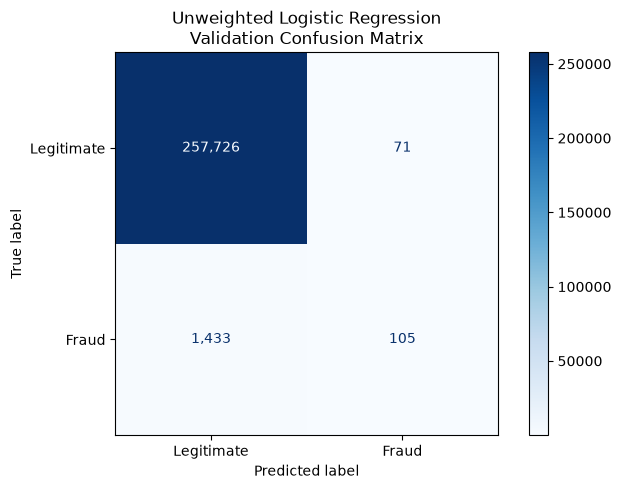

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    baseline_logistic_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d",
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Unweighted Logistic Regression\nValidation Confusion Matrix"
)

plt.tight_layout()
plt.show()

## Model 1B — Class-Weighted Logistic Regression

The second Logistic Regression experiment addresses the severe class imbalance using automatic class weighting.

Setting `class_weight="balanced"` assigns a larger training weight to the minority fraud class and a smaller weight to the majority legitimate class. The weights are calculated from the class frequencies in the development labels only.

No oversampling or undersampling is performed, so the original development observations remain unchanged. The chronological validation set is not used during model fitting.

The same sparse-compatible `saga` solver, L2 regularisation, regularisation strength, convergence tolerance, and random seed are retained to support a fair comparison with the unweighted baseline.

At this stage, the class-weighted model is only trained. Predictions and evaluation are completed separately.

In [66]:
from sklearn.linear_model import LogisticRegression
import time
import warnings
from sklearn.exceptions import ConvergenceWarning

weighted_logistic_regression = LogisticRegression(
    C=1.0,
    solver="saga",
    l1_ratio=0.0,
    class_weight="balanced",
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    verbose=1
)

print("Starting class-weighted Logistic Regression training...")
print("Development matrix shape:", X_development_processed.shape)

weighted_training_start_time = time.time()

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    weighted_logistic_regression.fit(
        X_development_processed,
        y_development
    )

weighted_logistic_training_seconds = (
    time.time() - weighted_training_start_time
)

weighted_convergence_warning = any(
    issubclass(warning.category, ConvergenceWarning)
    for warning in captured_warnings
)

print("\nClass-weighted Logistic Regression training completed.")
print(
    "Training time:",
    round(weighted_logistic_training_seconds, 2),
    "seconds"
)
print(
    "Iterations used:",
    weighted_logistic_regression.n_iter_[0]
)
print(
    "Convergence warning:",
    weighted_convergence_warning
)

Starting class-weighted Logistic Regression training...
Development matrix shape: (1037340, 1243)
max_iter reached after 777 seconds

Class-weighted Logistic Regression training completed.
Training time: 777.12 seconds
Iterations used: 1000
Convergence warning: True


### Class-Weighted Logistic Regression — Convergence Continuation

The initial class-weighted Logistic Regression training reached the maximum iteration limit before convergence.

Warm-start training is therefore used to continue optimisation from the coefficients already learned. This avoids restarting the lengthy training process and preserves the same model configuration, including balanced class weights and the chronological development data.

In [67]:
import time
import warnings
from sklearn.exceptions import ConvergenceWarning

weighted_logistic_regression.set_params(
    warm_start=True,
    max_iter=500,
    tol=1e-3,
    verbose=1
)

print(
    "Continuing class-weighted Logistic Regression "
    "from existing coefficients..."
)

weighted_continuation_start_time = time.time()

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    weighted_logistic_regression.fit(
        X_development_processed,
        y_development
    )

weighted_continuation_seconds = (
    time.time() - weighted_continuation_start_time
)

weighted_continuation_warning = any(
    issubclass(warning.category, ConvergenceWarning)
    for warning in captured_warnings
)

print("\nContinuation training completed.")
print(
    "Additional training time:",
    round(weighted_continuation_seconds, 2),
    "seconds"
)
print(
    "Iterations used during continuation:",
    weighted_logistic_regression.n_iter_[0]
)
print(
    "Convergence warning:",
    weighted_continuation_warning
)

Continuing class-weighted Logistic Regression from existing coefficients...
max_iter reached after 391 seconds

Continuation training completed.
Additional training time: 391.56 seconds
Iterations used during continuation: 500
Convergence warning: True


### Class-Weighted Logistic Regression — Solver Adjustment

The class-weighted Logistic Regression model did not converge after the initial training and one warm-start continuation.

Because the model uses only L2 regularisation, the optimiser is changed from `saga` to `sag`. The `sag` solver is suitable for large sparse datasets and may converge more efficiently for an L2-regularised Logistic Regression model.

Warm-start training is retained so that optimisation can continue from the coefficients already learned rather than restarting from random initial values. The model objective, class weights, development data, regularisation strength, and convergence tolerance remain unchanged.

In [68]:
import time
import warnings
from sklearn.exceptions import ConvergenceWarning

weighted_logistic_regression.set_params(
    solver="sag",
    warm_start=True,
    max_iter=1000,
    tol=1e-3,
    verbose=1
)

print(
    "Continuing class-weighted Logistic Regression "
    "using the SAG solver..."
)

sag_continuation_start_time = time.time()

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    weighted_logistic_regression.fit(
        X_development_processed,
        y_development
    )

sag_continuation_seconds = (
    time.time() - sag_continuation_start_time
)

sag_convergence_warning = any(
    issubclass(warning.category, ConvergenceWarning)
    for warning in captured_warnings
)

print("\nSAG continuation training completed.")
print(
    "Additional training time:",
    round(sag_continuation_seconds, 2),
    "seconds"
)
print(
    "Iterations used with SAG:",
    weighted_logistic_regression.n_iter_[0]
)
print(
    "Convergence warning:",
    sag_convergence_warning
)

Continuing class-weighted Logistic Regression using the SAG solver...
max_iter reached after 770 seconds

SAG continuation training completed.
Additional training time: 770.94 seconds
Iterations used with SAG: 1000
Convergence warning: True


### Class-Weighted Logistic Regression — Practical Convergence Tolerance

The class-weighted Logistic Regression model did not satisfy the original convergence tolerance after multiple optimisation attempts.

Class weighting makes the optimisation problem more difficult because errors from the rare fraud class receive substantially greater influence. A practical convergence tolerance of `1e-2` is therefore tested.

This adjustment does not change the predictors, class weights, regularisation strength, training observations, or model family. It only relaxes the stopping criterion used by the optimiser. Warm-start training is retained so that optimisation continues from the coefficients already learned.

In [69]:
import time
import warnings
from sklearn.exceptions import ConvergenceWarning

weighted_logistic_regression.set_params(
    solver="sag",
    warm_start=True,
    max_iter=500,
    tol=1e-2,
    verbose=1
)

print(
    "Continuing class-weighted Logistic Regression "
    "with practical tolerance..."
)

practical_tolerance_start_time = time.time()

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    weighted_logistic_regression.fit(
        X_development_processed,
        y_development
    )

practical_tolerance_training_seconds = (
    time.time() - practical_tolerance_start_time
)

practical_tolerance_warning = any(
    issubclass(warning.category, ConvergenceWarning)
    for warning in captured_warnings
)

print("\nPractical-tolerance training completed.")
print(
    "Additional training time:",
    round(practical_tolerance_training_seconds, 2),
    "seconds"
)
print(
    "Iterations used:",
    weighted_logistic_regression.n_iter_[0]
)
print(
    "Convergence warning:",
    practical_tolerance_warning
)

Continuing class-weighted Logistic Regression with practical tolerance...
max_iter reached after 386 seconds

Practical-tolerance training completed.
Additional training time: 386.39 seconds
Iterations used: 500
Convergence warning: True


### Class-Weighted Logistic Regression — Non-Convergence Outcome

The automatically balanced Logistic Regression model did not converge after repeated optimisation attempts using both the `saga` and `sag` solvers.

The model also failed to converge after relaxing the stopping tolerance from `1e-3` to `1e-2`. Further continuation was stopped because additional iterations were producing substantial computational cost without satisfying the convergence criterion.

The current fitted coefficients are retained for exploratory validation evaluation. However, the model is marked as non-converged, and this limitation must be considered when comparing it with other experiments.

In [70]:
import time

print(
    "Generating validation predictions from the "
    "non-converged class-weighted model..."
)

weighted_prediction_start_time = time.time()

weighted_logistic_validation_predictions = (
    weighted_logistic_regression.predict(
        X_validation_processed
    )
)

weighted_logistic_validation_probabilities = (
    weighted_logistic_regression.predict_proba(
        X_validation_processed
    )[:, 1]
)

weighted_prediction_seconds = (
    time.time() - weighted_prediction_start_time
)

print("Validation predictions generated.")
print(
    "Prediction time:",
    round(weighted_prediction_seconds, 2),
    "seconds"
)
print(
    "Predicted labels shape:",
    weighted_logistic_validation_predictions.shape
)
print(
    "Predicted probabilities shape:",
    weighted_logistic_validation_probabilities.shape
)
print(
    "Predicted fraud cases:",
    weighted_logistic_validation_predictions.sum()
)
print(
    "Minimum predicted fraud probability:",
    weighted_logistic_validation_probabilities.min()
)
print(
    "Maximum predicted fraud probability:",
    weighted_logistic_validation_probabilities.max()
)

Generating validation predictions from the non-converged class-weighted model...
Validation predictions generated.
Prediction time: 0.08 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 73014
Minimum predicted fraud probability: 1.0793773327157843e-46
Maximum predicted fraud probability: 1.0


### Exploratory Evaluation of the Non-Converged Class-Weighted Model

The non-converged class-weighted Logistic Regression model is evaluated on the unchanged chronological validation set.

The evaluation is retained to understand how automatic class weighting changed fraud detection behaviour relative to the unweighted baseline. However, the results must be interpreted cautiously because the optimiser did not satisfy the convergence criterion.

Particular attention is given to the trade-off between fraud recall and false positives.

In [71]:
weighted_logistic_results = evaluate_binary_classifier(
    model_name="Class-Weighted Logistic Regression (Non-Converged)",
    y_true=y_validation,
    y_pred=weighted_logistic_validation_predictions,
    y_probability=weighted_logistic_validation_probabilities
)

weighted_logistic_results

{'model': 'Class-Weighted Logistic Regression (Non-Converged)',
 'accuracy': 0.7176084986600343,
 'fraud_precision': 0.009025666310570576,
 'fraud_recall': 0.4284785435630689,
 'fraud_f1': 0.017678935508101727,
 'pr_auc': 0.01032775213000281,
 'roc_auc': 0.6260021676716399,
 'true_negatives': np.int64(185442),
 'false_positives': np.int64(72355),
 'false_negatives': np.int64(879),
 'true_positives': np.int64(659)}

## Model 1C — Moderately Weighted Logistic Regression

The automatically balanced Logistic Regression model produced an excessive number of false-positive fraud alerts and failed to converge.

A more controlled weighting strategy is therefore tested. The legitimate class retains a weight of `1`, while the fraud class receives a weight of `10`.

This moderate weighting aims to improve fraud recall without applying the extremely large minority-class weight generated by `class_weight="balanced"`.

A new model is trained from the beginning because changing class weights changes the optimisation objective. Only the development data is used during fitting, while the chronological validation set remains unchanged.

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import time
import warnings

moderate_weight_logistic_regression = LogisticRegression(
    C=1.0,
    solver="sag",
    l1_ratio=0.0,
    class_weight={0: 1, 1: 10},
    max_iter=1000,
    tol=1e-3,
    random_state=42,
    verbose=1
)

print("Starting moderately weighted Logistic Regression training...")
print("Class weights: legitimate = 1, fraud = 10")
print("Development matrix shape:", X_development_processed.shape)

moderate_weight_training_start_time = time.time()

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    moderate_weight_logistic_regression.fit(
        X_development_processed,
        y_development
    )

moderate_weight_training_seconds = (
    time.time() - moderate_weight_training_start_time
)

moderate_weight_convergence_warning = any(
    issubclass(warning.category, ConvergenceWarning)
    for warning in captured_warnings
)

print("\nModerately weighted Logistic Regression training completed.")
print(
    "Training time:",
    round(moderate_weight_training_seconds, 2),
    "seconds"
)
print(
    "Iterations used:",
    moderate_weight_logistic_regression.n_iter_[0]
)
print(
    "Convergence warning:",
    moderate_weight_convergence_warning
)

Starting moderately weighted Logistic Regression training...
Class weights: legitimate = 1, fraud = 10
Development matrix shape: (1037340, 1243)
convergence after 44 epochs took 34 seconds

Moderately weighted Logistic Regression training completed.
Training time: 34.71 seconds
Iterations used: 44
Convergence warning: False


### Generate Validation Predictions for Moderately Weighted Logistic Regression

The converged moderately weighted Logistic Regression model is applied to the unchanged chronological validation set.

Predicted class labels are generated using the default decision threshold of `0.5`. Predicted fraud probabilities are also retained for calculating threshold-independent metrics such as PR-AUC and ROC-AUC.

No evaluation metrics are calculated in this step.

In [73]:
import time

print(
    "Generating validation predictions for the "
    "moderately weighted Logistic Regression model..."
)

moderate_weight_prediction_start_time = time.time()

moderate_weight_validation_predictions = (
    moderate_weight_logistic_regression.predict(
        X_validation_processed
    )
)

moderate_weight_validation_probabilities = (
    moderate_weight_logistic_regression.predict_proba(
        X_validation_processed
    )[:, 1]
)

moderate_weight_prediction_seconds = (
    time.time() - moderate_weight_prediction_start_time
)

print("Validation predictions generated.")
print(
    "Prediction time:",
    round(moderate_weight_prediction_seconds, 2),
    "seconds"
)
print(
    "Predicted labels shape:",
    moderate_weight_validation_predictions.shape
)
print(
    "Predicted probabilities shape:",
    moderate_weight_validation_probabilities.shape
)
print(
    "Predicted fraud cases:",
    moderate_weight_validation_predictions.sum()
)
print(
    "Minimum predicted fraud probability:",
    moderate_weight_validation_probabilities.min()
)
print(
    "Maximum predicted fraud probability:",
    moderate_weight_validation_probabilities.max()
)

Generating validation predictions for the moderately weighted Logistic Regression model...
Validation predictions generated.
Prediction time: 0.03 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 1398
Minimum predicted fraud probability: 1.3114199226817364e-07
Maximum predicted fraud probability: 0.999968736962728


### Evaluate Moderately Weighted Logistic Regression

The moderately weighted Logistic Regression model is evaluated on the unchanged chronological validation set.

The evaluation compares fraud precision, fraud recall, fraud F1-score, PR-AUC, ROC-AUC, and confusion-matrix counts. Particular attention is given to whether the moderate class weight improves fraud detection while keeping false-positive alerts at a manageable level.

In [74]:
moderate_weight_logistic_results = evaluate_binary_classifier(
    model_name="Moderately Weighted Logistic Regression",
    y_true=y_validation,
    y_pred=moderate_weight_validation_predictions,
    y_probability=moderate_weight_validation_probabilities
)

moderate_weight_logistic_results

{'model': 'Moderately Weighted Logistic Regression',
 'accuracy': 0.9913779474424972,
 'fraud_precision': 0.2503576537911302,
 'fraud_recall': 0.22756827048114434,
 'fraud_f1': 0.23841961852861035,
 'pr_auc': 0.12890663902886426,
 'roc_auc': 0.7596978036765684,
 'true_negatives': np.int64(256749),
 'false_positives': np.int64(1048),
 'false_negatives': np.int64(1188),
 'true_positives': np.int64(350)}

### Moderately Weighted Logistic Regression Confusion Matrix

The confusion matrix shows how the moderate fraud-class weight changed classification behaviour at the default probability threshold of `0.5`.

Compared with the unweighted baseline, the model detects more fraudulent transactions and reduces false negatives. However, this improvement is accompanied by a larger number of legitimate transactions being incorrectly flagged as fraud.

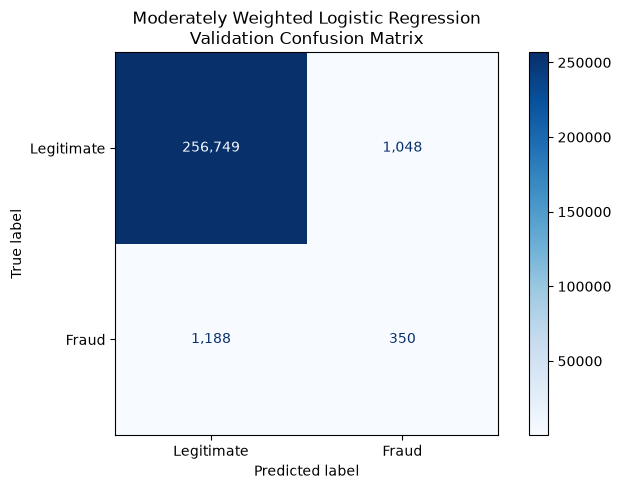

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    moderate_weight_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d",
    cmap="Blues",
    ax=ax
)

ax.set_title(
    "Moderately Weighted Logistic Regression\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

## Logistic Regression Experiment Comparison

Three Logistic Regression configurations were tested:

1. Unweighted Logistic Regression
2. Automatically balanced Logistic Regression
3. Moderately weighted Logistic Regression with fraud class weight `10`

The automatically balanced model did not converge and produced an excessive number of false-positive alerts. The comparison below records all results while clearly identifying the non-converged experiment.

The converged unweighted and moderately weighted models provide different operating trade-offs. The unweighted model achieves stronger probability-ranking metrics, while moderate weighting improves fraud recall and fraud F1-score at the default classification threshold.

In [76]:
import pandas as pd

logistic_regression_comparison = pd.DataFrame([
    {
        **baseline_logistic_results,
        "converged": True,
        "fraud_class_weight": 1
    },
    {
        **weighted_logistic_results,
        "converged": False,
        "fraud_class_weight": "balanced"
    },
    {
        **moderate_weight_logistic_results,
        "converged": True,
        "fraud_class_weight": 10
    }
])

comparison_columns = [
    "model",
    "converged",
    "fraud_class_weight",
    "fraud_precision",
    "fraud_recall",
    "fraud_f1",
    "pr_auc",
    "roc_auc",
    "false_positives",
    "false_negatives",
    "true_positives"
]

logistic_regression_comparison = (
    logistic_regression_comparison[comparison_columns]
    .sort_values(
        by=["converged", "fraud_f1"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

logistic_regression_comparison

,model,converged,fraud_class_weight,fraud_precision,fraud_recall,fraud_f1,pr_auc,roc_auc,false_positives,false_negatives,true_positives
0,Moderately Weighted Logistic Regression,True,10,0.2504,0.2276,0.2384,0.1289,0.7597,1048,1188,350
1,Unweighted Logistic Regression,True,1,0.5966,0.0683,0.1225,0.2466,0.8139,71,1433,105
2,Class-Weighted Logistic Regression (Non-Conver...,False,balanced,0.0090,0.4285,0.0177,0.0103,0.6260,72355,879,659


## Model 2A — Unweighted Random Forest Baseline

The second model family is a Random Forest classifier trained using the original class distribution without class weighting or resampling.

Random Forest combines multiple decision trees trained using bootstrap samples and randomly selected feature subsets. This allows the model to capture non-linear relationships and feature interactions that Logistic Regression may not represent.

Because the processed development dataset contains more than one million rows and 1,243 sparse features, the baseline uses a computationally controlled configuration. The number and depth of trees, bootstrap sample size, and number of features considered at each split are restricted to reduce training time and memory usage.

No imbalance treatment is applied in this baseline. Its performance will later provide a reference for evaluating imbalance-aware Random Forest configurations.

In [77]:
from sklearn.ensemble import RandomForestClassifier
import time

unweighted_random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.30,
    class_weight=None,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training unweighted Random Forest baseline...")

random_forest_training_start_time = time.time()

unweighted_random_forest.fit(
    X_development_processed,
    y_development
)

random_forest_training_time_seconds = (
    time.time() - random_forest_training_start_time
)

print("\nUnweighted Random Forest training completed.")

print(
    "Training time:",
    round(random_forest_training_time_seconds / 60, 2),
    "minutes"
)

print(
    "Number of fitted trees:",
    len(unweighted_random_forest.estimators_)
)

Training unweighted Random Forest baseline...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   13.1s



Unweighted Random Forest training completed.
Training time: 0.6 minutes
Number of fitted trees: 100


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   35.3s finished


### Generate Random Forest Validation Predictions

The trained unweighted Random Forest is now applied to the unchanged chronological validation set.

Two outputs are generated:

- Predicted class labels using the default classification threshold of `0.5`
- Predicted fraud probabilities for later calculation of PR-AUC and ROC-AUC

The validation data is used only for prediction and is not involved in model training. No evaluation metrics are calculated in this step.

In [78]:
import time

print("Generating unweighted Random Forest validation predictions...")

random_forest_prediction_start_time = time.time()

unweighted_random_forest_validation_predictions = (
    unweighted_random_forest.predict(
        X_validation_processed
    )
)

unweighted_random_forest_validation_probabilities = (
    unweighted_random_forest.predict_proba(
        X_validation_processed
    )[:, 1]
)

random_forest_prediction_time_seconds = (
    time.time() - random_forest_prediction_start_time
)

print("\nValidation predictions generated.")

print(
    "Prediction time:",
    round(random_forest_prediction_time_seconds, 2),
    "seconds"
)

print(
    "Predicted labels shape:",
    unweighted_random_forest_validation_predictions.shape
)

print(
    "Predicted probabilities shape:",
    unweighted_random_forest_validation_probabilities.shape
)

print(
    "Predicted fraud cases:",
    unweighted_random_forest_validation_predictions.sum()
)

print(
    "Minimum predicted fraud probability:",
    unweighted_random_forest_validation_probabilities.min()
)

print(
    "Maximum predicted fraud probability:",
    unweighted_random_forest_validation_probabilities.max()
)

Generating unweighted Random Forest validation predictions...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s



Validation predictions generated.
Prediction time: 1.38 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 21
Minimum predicted fraud probability: 0.0015154285773478502
Maximum predicted fraud probability: 0.6385687676443407


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished


### Evaluate the Unweighted Random Forest Baseline

The unweighted Random Forest is evaluated on the unchanged chronological validation set using the default classification threshold of `0.5`.

The evaluation includes fraud-class precision, recall and F1-score, together with PR-AUC, ROC-AUC and confusion-matrix counts. PR-AUC is especially important because fraudulent transactions are rare and overall accuracy can therefore be misleading.

This evaluation establishes the baseline performance of the Random Forest model before introducing any class weighting or other imbalance-handling strategy.

In [79]:
unweighted_random_forest_results = evaluate_binary_classifier(
    model_name="Unweighted Random Forest",
    y_true=y_validation,
    y_pred=unweighted_random_forest_validation_predictions,
    y_probability=unweighted_random_forest_validation_probabilities
)

unweighted_random_forest_results

{'model': 'Unweighted Random Forest',
 'accuracy': 0.9941504231977943,
 'fraud_precision': 1.0,
 'fraud_recall': 0.013654096228868661,
 'fraud_f1': 0.026940346375881975,
 'pr_auc': 0.6691220416195018,
 'roc_auc': 0.9654852988555984,
 'true_negatives': np.int64(257797),
 'false_positives': np.int64(0),
 'false_negatives': np.int64(1517),
 'true_positives': np.int64(21)}

### Confusion Matrix — Unweighted Random Forest

The confusion matrix shows the number of legitimate and fraudulent transactions classified correctly and incorrectly by the unweighted Random Forest at the default probability threshold of `0.5`.

This visual helps reveal the effect of class imbalance more clearly than overall accuracy. In particular, it shows whether the model is producing excessive false positives or missing fraudulent transactions as false negatives.

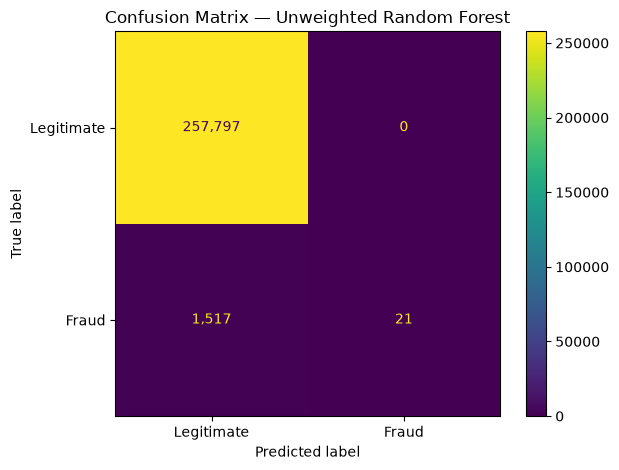

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    unweighted_random_forest_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d"
)

plt.title("Confusion Matrix — Unweighted Random Forest")
plt.tight_layout()
plt.show()

## Model 2B — Moderately Weighted Random Forest

The unweighted Random Forest achieved strong probability-ranking performance but detected very few fraudulent transactions at the default threshold. This behaviour indicates that the model is strongly influenced by the dominant legitimate class.

A moderately weighted Random Forest is therefore trained using `class_weight={0: 1, 1: 10}`. This assigns a greater penalty to misclassified fraud cases while avoiding the potentially excessive effect of fully automatic class balancing.

All other Random Forest settings are kept unchanged. This supports a controlled comparison in which the class-weight configuration is the main experimental difference.

The chronological validation set remains unchanged, and no resampling is applied.

In [81]:
from sklearn.ensemble import RandomForestClassifier
import time

moderately_weighted_random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    max_samples=0.30,
    class_weight={0: 1, 1: 10},
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training moderately weighted Random Forest...")

weighted_random_forest_training_start_time = time.time()

moderately_weighted_random_forest.fit(
    X_development_processed,
    y_development
)

weighted_random_forest_training_time_seconds = (
    time.time() - weighted_random_forest_training_start_time
)

print("\nModerately weighted Random Forest training completed.")

print(
    "Training time:",
    round(weighted_random_forest_training_time_seconds / 60, 2),
    "minutes"
)

print(
    "Number of fitted trees:",
    len(moderately_weighted_random_forest.estimators_)
)

Training moderately weighted Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   15.8s



Moderately weighted Random Forest training completed.
Training time: 0.71 minutes
Number of fitted trees: 100


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   42.0s finished


### Generate Moderately Weighted Random Forest Validation Predictions

The trained moderately weighted Random Forest is now applied to the unchanged chronological validation set.

Predicted class labels are generated using the default classification threshold of `0.5`, together with fraud probabilities required for later PR-AUC and ROC-AUC calculation.

The validation set is used only for prediction. No evaluation metrics are calculated in this step.

In [82]:
import time

print(
    "Generating moderately weighted Random Forest "
    "validation predictions..."
)

weighted_random_forest_prediction_start_time = time.time()

moderately_weighted_random_forest_validation_predictions = (
    moderately_weighted_random_forest.predict(
        X_validation_processed
    )
)

moderately_weighted_random_forest_validation_probabilities = (
    moderately_weighted_random_forest.predict_proba(
        X_validation_processed
    )[:, 1]
)

weighted_random_forest_prediction_time_seconds = (
    time.time() - weighted_random_forest_prediction_start_time
)

print("\nValidation predictions generated.")

print(
    "Prediction time:",
    round(weighted_random_forest_prediction_time_seconds, 2),
    "seconds"
)

print(
    "Predicted labels shape:",
    moderately_weighted_random_forest_validation_predictions.shape
)

print(
    "Predicted probabilities shape:",
    moderately_weighted_random_forest_validation_probabilities.shape
)

print(
    "Predicted fraud cases:",
    moderately_weighted_random_forest_validation_predictions.sum()
)

print(
    "Minimum predicted fraud probability:",
    moderately_weighted_random_forest_validation_probabilities.min()
)

print(
    "Maximum predicted fraud probability:",
    moderately_weighted_random_forest_validation_probabilities.max()
)

Generating moderately weighted Random Forest validation predictions...


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s



Validation predictions generated.
Prediction time: 1.57 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 366
Minimum predicted fraud probability: 0.013291180191292653
Maximum predicted fraud probability: 0.7920678621275984


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished


### Evaluate the Moderately Weighted Random Forest

The moderately weighted Random Forest is evaluated on the unchanged chronological validation set using the default classification threshold of `0.5`.

The evaluation measures fraud precision, fraud recall, fraud F1-score, PR-AUC, ROC-AUC, and the confusion-matrix counts.

These results will show whether assigning greater importance to the fraud class improves fraud detection without creating an excessive number of false positives.

In [83]:
moderately_weighted_random_forest_results = evaluate_binary_classifier(
    model_name="Moderately Weighted Random Forest",
    y_true=y_validation,
    y_pred=moderately_weighted_random_forest_validation_predictions,
    y_probability=moderately_weighted_random_forest_validation_probabilities
)

moderately_weighted_random_forest_results

{'model': 'Moderately Weighted Random Forest',
 'accuracy': 0.995434476642181,
 'fraud_precision': 0.9836065573770492,
 'fraud_recall': 0.2340702210663199,
 'fraud_f1': 0.37815126050420167,
 'pr_auc': 0.6883265614166162,
 'roc_auc': 0.970293447642822,
 'true_negatives': np.int64(257791),
 'false_positives': np.int64(6),
 'false_negatives': np.int64(1178),
 'true_positives': np.int64(360)}

### Confusion Matrix — Moderately Weighted Random Forest

The confusion matrix visualises the validation predictions produced by the moderately weighted Random Forest at the default threshold of `0.5`.

It shows how the increased fraud-class weight changes the balance between detecting fraudulent transactions and incorrectly flagging legitimate transactions. The matrix should be compared directly with the unweighted Random Forest confusion matrix.

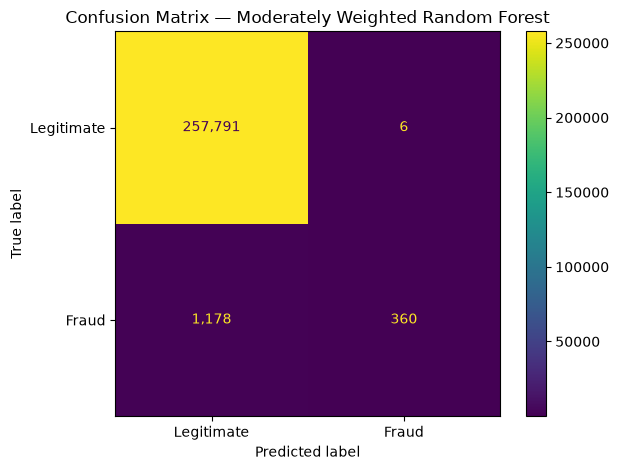

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    moderately_weighted_random_forest_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d"
)

plt.title("Confusion Matrix — Moderately Weighted Random Forest")
plt.tight_layout()
plt.show()

### Random Forest Model Comparison

The unweighted and moderately weighted Random Forest models are compared using fraud-focused evaluation metrics and confusion-matrix counts.

This comparison shows the effect of assigning additional importance to fraudulent transactions while keeping the model structure and validation data unchanged.

Accuracy is included only for completeness. Model comparison is based primarily on fraud precision, fraud recall, fraud F1-score, PR-AUC, ROC-AUC, false positives, false negatives, and true positives.

In [85]:
import pandas as pd

random_forest_comparison = pd.DataFrame([
    unweighted_random_forest_results,
    moderately_weighted_random_forest_results
])

random_forest_comparison = random_forest_comparison[
    [
        "model",
        "accuracy",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "pr_auc",
        "roc_auc",
        "false_positives",
        "false_negatives",
        "true_positives"
    ]
].copy()

metric_columns = [
    "accuracy",
    "fraud_precision",
    "fraud_recall",
    "fraud_f1",
    "pr_auc",
    "roc_auc"
]

random_forest_comparison[metric_columns] = (
    random_forest_comparison[metric_columns].round(4)
)

random_forest_comparison

,model,accuracy,fraud_precision,fraud_recall,fraud_f1,pr_auc,roc_auc,false_positives,false_negatives,true_positives
0,Unweighted Random Forest,0.9942,1.0000,0.0137,0.0269,0.6691,0.9655,0,1517,21
1,Moderately Weighted Random Forest,0.9954,0.9836,0.2341,0.3782,0.6883,0.9703,6,1178,360


## Model 3A — Unweighted XGBoost Baseline

The third model family is Extreme Gradient Boosting, implemented using `XGBClassifier`.

Unlike Random Forest, which trains independent trees and combines their predictions, XGBoost builds trees sequentially. Each new tree attempts to correct errors made by the existing ensemble. This allows the model to learn complex non-linear relationships and feature interactions.

An unweighted baseline is trained first using the original class distribution. No class weighting or resampling is applied at this stage.

Because the development dataset contains more than one million rows and 1,243 sparse features, a computationally controlled configuration is used. Histogram-based tree construction, row subsampling, feature subsampling, and a restricted tree depth are applied to control memory usage and training time.

The model is trained only on the processed development data. The chronological validation set remains unchanged and is not used during training.

In [86]:
from xgboost import XGBClassifier
import time

unweighted_xgboost = XGBClassifier(
    n_estimators=150,
    learning_rate=0.10,
    max_depth=6,
    min_child_weight=5,
    subsample=0.30,
    colsample_bytree=0.50,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    max_bin=256,
    n_jobs=-1,
    random_state=42
)

print("Training unweighted XGBoost baseline...")

xgboost_training_start_time = time.time()

unweighted_xgboost.fit(
    X_development_processed,
    y_development
)

xgboost_training_time_seconds = (
    time.time() - xgboost_training_start_time
)

print("\nUnweighted XGBoost training completed.")

print(
    "Training time:",
    round(xgboost_training_time_seconds / 60, 2),
    "minutes"
)

print(
    "Number of boosting trees:",
    unweighted_xgboost.n_estimators
)

ModuleNotFoundError: No module named 'xgboost'

### Install the XGBoost Library

The current notebook environment does not contain the `xgboost` package required for the third model family.

The package is installed before importing `XGBClassifier`. This installation affects only the notebook environment and does not use the development or validation data.

In [87]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
    --------------------------------------- 1.0/69.5 MB 3.0 MB/s eta 0:00:24
   - -------------------------------------- 1.8/69.5 MB 3.4 MB/s eta 0:00:20
   - -------------------------------------- 2.9/69.5 MB 4.0 MB/s eta 0:00:17
   -- ------------------------------------- 3.9/69.5 MB 4.2 MB/s eta 0:00:16
   --- ------------------------------------ 5.2/69.5 MB 4.5 MB/s eta 0:00:15
   --- ------------------------------------ 6.3/69.5 MB 4.6 MB/s eta 0:00:14
   ---- ----------------------------------- 7.3/69.5 MB 4.7 MB/s eta 0:00:14
   ---- ----------------------------------- 8.7/69.5 MB 4.9 MB/s eta 0:00:13
   ----- ---------------------------------- 10.0/69.5 MB 5.0 MB/s eta 0:00:13
   ------ --------------------------------- 10.7/69.5 MB 4.9 MB/s eta 0:00:13
   ------ --------

In [88]:
from xgboost import XGBClassifier
import time

unweighted_xgboost = XGBClassifier(
    n_estimators=150,
    learning_rate=0.10,
    max_depth=6,
    min_child_weight=5,
    subsample=0.30,
    colsample_bytree=0.50,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    max_bin=256,
    n_jobs=-1,
    random_state=42
)

print("Training unweighted XGBoost baseline...")

xgboost_training_start_time = time.time()

unweighted_xgboost.fit(
    X_development_processed,
    y_development
)

xgboost_training_time_seconds = (
    time.time() - xgboost_training_start_time
)

print("\nUnweighted XGBoost training completed.")

print(
    "Training time:",
    round(xgboost_training_time_seconds / 60, 2),
    "minutes"
)

print(
    "Number of boosting trees:",
    unweighted_xgboost.n_estimators
)

Training unweighted XGBoost baseline...

Unweighted XGBoost training completed.
Training time: 0.25 minutes
Number of boosting trees: 150


### Generate Unweighted XGBoost Validation Predictions

The trained unweighted XGBoost model is now applied to the unchanged chronological validation set.

Predicted class labels are generated using the default classification threshold of `0.5`. Fraud probabilities are also generated for later calculation of PR-AUC and ROC-AUC.

The validation data is used only for prediction and is not involved in model training. No evaluation metrics are calculated in this step.

In [89]:
import time

print("Generating unweighted XGBoost validation predictions...")

xgboost_prediction_start_time = time.time()

unweighted_xgboost_validation_predictions = (
    unweighted_xgboost.predict(
        X_validation_processed
    )
)

unweighted_xgboost_validation_probabilities = (
    unweighted_xgboost.predict_proba(
        X_validation_processed
    )[:, 1]
)

xgboost_prediction_time_seconds = (
    time.time() - xgboost_prediction_start_time
)

print("\nValidation predictions generated.")

print(
    "Prediction time:",
    round(xgboost_prediction_time_seconds, 2),
    "seconds"
)

print(
    "Predicted labels shape:",
    unweighted_xgboost_validation_predictions.shape
)

print(
    "Predicted probabilities shape:",
    unweighted_xgboost_validation_probabilities.shape
)

print(
    "Predicted fraud cases:",
    int(unweighted_xgboost_validation_predictions.sum())
)

print(
    "Minimum predicted fraud probability:",
    unweighted_xgboost_validation_probabilities.min()
)

print(
    "Maximum predicted fraud probability:",
    unweighted_xgboost_validation_probabilities.max()
)

Generating unweighted XGBoost validation predictions...

Validation predictions generated.
Prediction time: 1.94 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 1215
Minimum predicted fraud probability: 5.392675e-06
Maximum predicted fraud probability: 0.99600357


### Evaluate the Unweighted XGBoost Baseline

The unweighted XGBoost model is evaluated on the unchanged chronological validation set using the default classification threshold of `0.5`.

The evaluation includes fraud precision, fraud recall, fraud F1-score, PR-AUC, ROC-AUC, and confusion-matrix counts.

These results establish the baseline performance of the XGBoost model before applying any imbalance-aware weighting.

In [90]:
unweighted_xgboost_results = evaluate_binary_classifier(
    model_name="Unweighted XGBoost",
    y_true=y_validation,
    y_pred=unweighted_xgboost_validation_predictions,
    y_probability=unweighted_xgboost_validation_probabilities
)

unweighted_xgboost_results

{'model': 'Unweighted XGBoost',
 'accuracy': 0.9982223764628761,
 'fraud_precision': 0.9432098765432099,
 'fraud_recall': 0.7451235370611183,
 'fraud_f1': 0.8325463131129677,
 'pr_auc': 0.8989983492501761,
 'roc_auc': 0.9974748026684215,
 'true_negatives': np.int64(257728),
 'false_positives': np.int64(69),
 'false_negatives': np.int64(392),
 'true_positives': np.int64(1146)}

### Confusion Matrix — Unweighted XGBoost

The confusion matrix visualises the validation predictions produced by the unweighted XGBoost model at the default classification threshold of `0.5`.

It shows the number of correctly detected fraud cases, missed fraud cases, and legitimate transactions incorrectly flagged as fraud. This provides a direct view of the trade-off between fraud detection and false alarms.

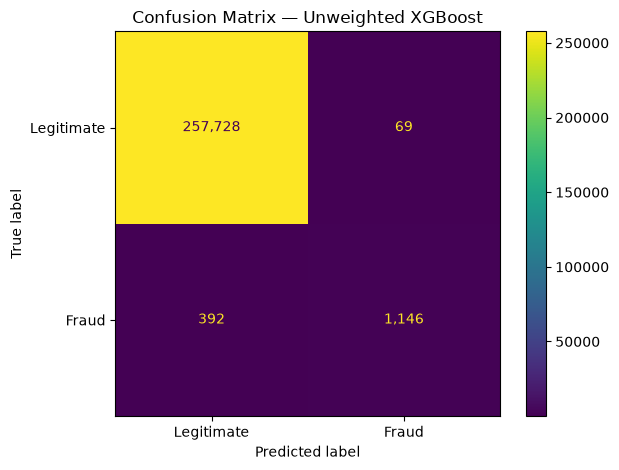

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    unweighted_xgboost_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d"
)

plt.title("Confusion Matrix — Unweighted XGBoost")
plt.tight_layout()
plt.show()

## Model 3B — Moderately Weighted XGBoost

The unweighted XGBoost baseline achieved strong fraud detection performance, but 392 fraudulent transactions were still missed.

A moderately weighted XGBoost model is therefore trained using `scale_pos_weight=10`. This increases the penalty associated with misclassifying fraudulent transactions and may improve fraud recall.

All other XGBoost hyperparameters are kept unchanged to support a controlled comparison. No resampling is applied, and the chronological validation set remains untouched during training.

In [92]:
from xgboost import XGBClassifier
import time

moderately_weighted_xgboost = XGBClassifier(
    n_estimators=150,
    learning_rate=0.10,
    max_depth=6,
    min_child_weight=5,
    subsample=0.30,
    colsample_bytree=0.50,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    max_bin=256,
    scale_pos_weight=10,
    n_jobs=-1,
    random_state=42
)

print("Training moderately weighted XGBoost...")

weighted_xgboost_training_start_time = time.time()

moderately_weighted_xgboost.fit(
    X_development_processed,
    y_development
)

weighted_xgboost_training_time_seconds = (
    time.time() - weighted_xgboost_training_start_time
)

print("\nModerately weighted XGBoost training completed.")

print(
    "Training time:",
    round(weighted_xgboost_training_time_seconds / 60, 2),
    "minutes"
)

print(
    "Number of boosting trees:",
    moderately_weighted_xgboost.n_estimators
)

Training moderately weighted XGBoost...

Moderately weighted XGBoost training completed.
Training time: 0.25 minutes
Number of boosting trees: 150


### Generate Moderately Weighted XGBoost Validation Predictions

The trained moderately weighted XGBoost model is now applied to the unchanged chronological validation set.

Predicted class labels are generated using the default classification threshold of `0.5`. Predicted fraud probabilities are also generated for later calculation of PR-AUC and ROC-AUC.

The validation set is used only for prediction and is not involved in model training. No evaluation metrics are calculated in this step.

In [93]:
import time

print(
    "Generating moderately weighted XGBoost "
    "validation predictions..."
)

weighted_xgboost_prediction_start_time = time.time()

moderately_weighted_xgboost_validation_predictions = (
    moderately_weighted_xgboost.predict(
        X_validation_processed
    )
)

moderately_weighted_xgboost_validation_probabilities = (
    moderately_weighted_xgboost.predict_proba(
        X_validation_processed
    )[:, 1]
)

weighted_xgboost_prediction_time_seconds = (
    time.time() - weighted_xgboost_prediction_start_time
)

print("\nValidation predictions generated.")

print(
    "Prediction time:",
    round(weighted_xgboost_prediction_time_seconds, 2),
    "seconds"
)

print(
    "Predicted labels shape:",
    moderately_weighted_xgboost_validation_predictions.shape
)

print(
    "Predicted probabilities shape:",
    moderately_weighted_xgboost_validation_probabilities.shape
)

print(
    "Predicted fraud cases:",
    int(moderately_weighted_xgboost_validation_predictions.sum())
)

print(
    "Minimum predicted fraud probability:",
    moderately_weighted_xgboost_validation_probabilities.min()
)

print(
    "Maximum predicted fraud probability:",
    moderately_weighted_xgboost_validation_probabilities.max()
)

Generating moderately weighted XGBoost validation predictions...

Validation predictions generated.
Prediction time: 1.11 seconds
Predicted labels shape: (259335,)
Predicted probabilities shape: (259335,)
Predicted fraud cases: 1805
Minimum predicted fraud probability: 8.146632e-05
Maximum predicted fraud probability: 0.9990345


### Evaluate the Moderately Weighted XGBoost Model

The moderately weighted XGBoost model is evaluated on the unchanged chronological validation set using the default classification threshold of `0.5`.

The evaluation includes fraud precision, fraud recall, fraud F1-score, PR-AUC, ROC-AUC, and confusion-matrix counts.

These results will show whether increasing the fraud-class weight improves fraud detection while maintaining an acceptable number of false positives.

In [94]:
moderately_weighted_xgboost_results = evaluate_binary_classifier(
    model_name="Moderately Weighted XGBoost",
    y_true=y_validation,
    y_pred=moderately_weighted_xgboost_validation_predictions,
    y_probability=moderately_weighted_xgboost_validation_probabilities
)

moderately_weighted_xgboost_results

{'model': 'Moderately Weighted XGBoost',
 'accuracy': 0.9972660844081979,
 'fraud_precision': 0.7296398891966759,
 'fraud_recall': 0.8563068920676203,
 'fraud_f1': 0.7879150463655399,
 'pr_auc': 0.8958304992316014,
 'roc_auc': 0.9977027746042638,
 'true_negatives': np.int64(257309),
 'false_positives': np.int64(488),
 'false_negatives': np.int64(221),
 'true_positives': np.int64(1317)}

### Confusion Matrix — Moderately Weighted XGBoost

The confusion matrix visualises the validation predictions produced by the moderately weighted XGBoost model at the default classification threshold of `0.5`.

It shows whether the increased fraud-class weight improves the number of detected fraud cases and the associated increase in legitimate transactions incorrectly flagged as fraud.

This matrix should be compared directly with the unweighted XGBoost confusion matrix.

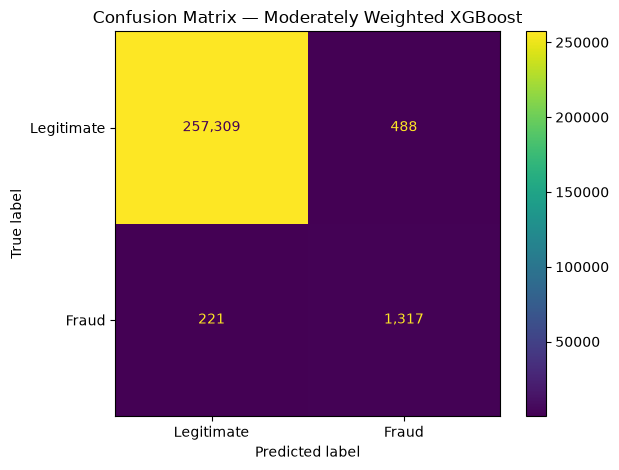

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    moderately_weighted_xgboost_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d"
)

plt.title("Confusion Matrix — Moderately Weighted XGBoost")
plt.tight_layout()
plt.show()

### XGBoost Model Comparison

The unweighted and moderately weighted XGBoost models are compared using fraud-focused evaluation metrics and confusion-matrix counts.

This comparison shows the effect of increasing the importance of fraudulent transactions while keeping the remaining XGBoost configuration unchanged.

The unweighted model prioritises precision and overall F1-score, while the moderately weighted model prioritises fraud recall. PR-AUC is used to compare their probability-ranking performance independently of the default classification threshold.

In [96]:
import pandas as pd

xgboost_comparison = pd.DataFrame([
    unweighted_xgboost_results,
    moderately_weighted_xgboost_results
])

xgboost_comparison = xgboost_comparison[
    [
        "model",
        "accuracy",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "pr_auc",
        "roc_auc",
        "false_positives",
        "false_negatives",
        "true_positives"
    ]
].copy()

metric_columns = [
    "accuracy",
    "fraud_precision",
    "fraud_recall",
    "fraud_f1",
    "pr_auc",
    "roc_auc"
]

xgboost_comparison[metric_columns] = (
    xgboost_comparison[metric_columns].round(4)
)

xgboost_comparison

,model,accuracy,fraud_precision,fraud_recall,fraud_f1,pr_auc,roc_auc,false_positives,false_negatives,true_positives
0,Unweighted XGBoost,0.9982,0.9432,0.7451,0.8325,0.8990,0.9975,69,392,1146
1,Moderately Weighted XGBoost,0.9973,0.7296,0.8563,0.7879,0.8958,0.9977,488,221,1317


## Overall Validation Model Comparison

All completed Logistic Regression, Random Forest, and XGBoost experiments are compared using the same unchanged chronological validation set.

The comparison focuses on fraud precision, fraud recall, fraud F1-score, PR-AUC, ROC-AUC, and confusion-matrix counts. Accuracy is retained only for completeness because the strong class imbalance makes it unsuitable as the main model-selection metric.

This table supports evidence-based comparison across the three different model families before selecting or refining the final candidate.

In [99]:
import pandas as pd

overall_model_comparison = pd.DataFrame([
    baseline_logistic_results,
    weighted_logistic_results,
    moderate_weight_logistic_results,
    unweighted_random_forest_results,
    moderately_weighted_random_forest_results,
    unweighted_xgboost_results,
    moderately_weighted_xgboost_results
])

overall_model_comparison = overall_model_comparison[
    [
        "model",
        "accuracy",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "pr_auc",
        "roc_auc",
        "false_positives",
        "false_negatives",
        "true_positives"
    ]
].copy()

metric_columns = [
    "accuracy",
    "fraud_precision",
    "fraud_recall",
    "fraud_f1",
    "pr_auc",
    "roc_auc"
]

overall_model_comparison[metric_columns] = (
    overall_model_comparison[metric_columns].round(4)
)

overall_model_comparison = (
    overall_model_comparison
    .sort_values(
        by=["pr_auc", "fraud_f1"],
        ascending=False
    )
    .reset_index(drop=True)
)

overall_model_comparison

,model,accuracy,fraud_precision,fraud_recall,fraud_f1,pr_auc,roc_auc,false_positives,false_negatives,true_positives
0,Unweighted XGBoost,0.9982,0.9432,0.7451,0.8325,0.8990,0.9975,69,392,1146
1,Moderately Weighted XGBoost,0.9973,0.7296,0.8563,0.7879,0.8958,0.9977,488,221,1317
2,Moderately Weighted Random Forest,0.9954,0.9836,0.2341,0.3782,0.6883,0.9703,6,1178,360
3,Unweighted Random Forest,0.9942,1.0000,0.0137,0.0269,0.6691,0.9655,0,1517,21
4,Unweighted Logistic Regression,0.9942,0.5966,0.0683,0.1225,0.2466,0.8139,71,1433,105
5,Moderately Weighted Logistic Regression,0.9914,0.2504,0.2276,0.2384,0.1289,0.7597,1048,1188,350
6,Class-Weighted Logistic Regression (Non-Conver...,0.7176,0.0090,0.4285,0.0177,0.0103,0.6260,72355,879,659


## Validation Threshold Analysis — Unweighted XGBoost

The unweighted XGBoost model currently provides the strongest fraud F1-score and PR-AUC at the default classification threshold of `0.5`.

However, the threshold determines how predicted fraud probabilities are converted into class labels. Lowering the threshold may detect more fraudulent transactions but can also increase false positives, while raising it may improve precision but miss more fraud cases.

The unchanged chronological validation set is used to examine several candidate thresholds and identify the threshold that maximises fraud F1-score. The final test dataset remains untouched.

In [100]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate precision and recall across all available thresholds
precision_values, recall_values, threshold_values = precision_recall_curve(
    y_validation,
    unweighted_xgboost_validation_probabilities
)

# The final precision and recall values do not have a matching threshold
threshold_f1_values = (
    2
    * precision_values[:-1]
    * recall_values[:-1]
    / (
        precision_values[:-1]
        + recall_values[:-1]
        + 1e-12
    )
)

best_f1_index = np.argmax(threshold_f1_values)
best_f1_threshold = threshold_values[best_f1_index]

print(
    "Threshold that maximises validation fraud F1:",
    round(float(best_f1_threshold), 4)
)

print(
    "Maximum validation fraud F1:",
    round(float(threshold_f1_values[best_f1_index]), 4)
)

# Compare several interpretable candidate thresholds
candidate_thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    float(best_f1_threshold)
]

threshold_results = []

for threshold in candidate_thresholds:
    threshold_predictions = (
        unweighted_xgboost_validation_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        threshold_predictions
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "fraud_precision": precision_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "fraud_recall": recall_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "fraud_f1": f1_score(
            y_validation,
            threshold_predictions,
            zero_division=0
        ),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

unweighted_xgboost_threshold_comparison = pd.DataFrame(
    threshold_results
)

unweighted_xgboost_threshold_comparison[
    [
        "threshold",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1"
    ]
] = unweighted_xgboost_threshold_comparison[
    [
        "threshold",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1"
    ]
].round(4)

unweighted_xgboost_threshold_comparison = (
    unweighted_xgboost_threshold_comparison
    .drop_duplicates(subset="threshold")
    .sort_values("threshold")
    .reset_index(drop=True)
)

unweighted_xgboost_threshold_comparison

Threshold that maximises validation fraud F1: 0.3238
Maximum validation fraud F1: 0.8457


,threshold,fraud_precision,fraud_recall,fraud_f1,false_positives,false_negatives,true_positives
0,0.2000,0.8283,0.8251,0.8267,263,269,1269
1,0.3000,0.8855,0.8043,0.8429,160,301,1237
2,0.3238,0.8948,0.8017,0.8457,145,305,1233
3,0.4000,0.9174,0.7802,0.8433,108,338,1200
4,0.5000,0.9432,0.7451,0.8325,69,392,1146
5,0.6000,0.9601,0.7035,0.8120,45,456,1082


### Evaluate Unweighted XGBoost Using the Selected Threshold

The validation threshold analysis identified approximately `0.3238` as the threshold that maximises fraud F1-score for the unweighted XGBoost model.

This threshold is now applied to the existing validation fraud probabilities to create revised class predictions. The model is not retrained, and the chronological validation set remains unchanged.

The revised predictions are evaluated using the same fraud-focused metrics and confusion-matrix counts used for all previous model experiments.

In [101]:
selected_xgboost_threshold = float(best_f1_threshold)

unweighted_xgboost_tuned_validation_predictions = (
    unweighted_xgboost_validation_probabilities
    >= selected_xgboost_threshold
).astype(int)

unweighted_xgboost_tuned_threshold_results = (
    evaluate_binary_classifier(
        model_name=(
            "Unweighted XGBoost "
            f"(Threshold={selected_xgboost_threshold:.4f})"
        ),
        y_true=y_validation,
        y_pred=unweighted_xgboost_tuned_validation_predictions,
        y_probability=(
            unweighted_xgboost_validation_probabilities
        )
    )
)

unweighted_xgboost_tuned_threshold_results

{'model': 'Unweighted XGBoost (Threshold=0.3238)',
 'accuracy': 0.9982647926427208,
 'fraud_precision': 0.8947750362844702,
 'fraud_recall': 0.8016905071521456,
 'fraud_f1': 0.845679012345679,
 'pr_auc': 0.8989983492501761,
 'roc_auc': 0.9974748026684215,
 'true_negatives': np.int64(257652),
 'false_positives': np.int64(145),
 'false_negatives': np.int64(305),
 'true_positives': np.int64(1233)}

### Confusion Matrix — Unweighted XGBoost with Selected Threshold

The confusion matrix visualises the unweighted XGBoost predictions after applying the validation-selected threshold of approximately `0.3238`.

Compared with the default threshold of `0.5`, the lower threshold is expected to detect more fraudulent transactions while also increasing the number of legitimate transactions incorrectly flagged as fraud.

This visual supports direct comparison between the default-threshold and selected-threshold versions of the same trained model.

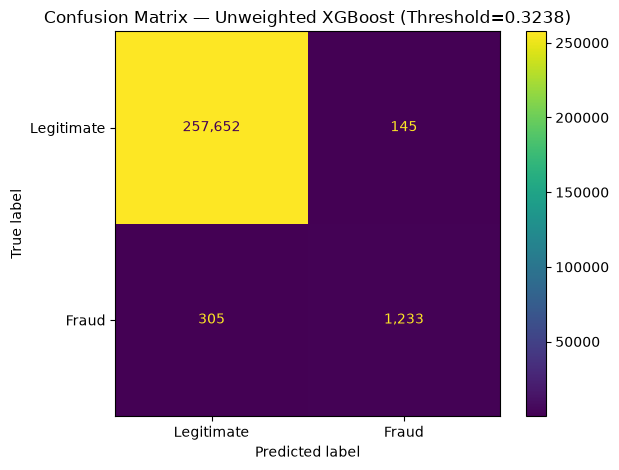

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    unweighted_xgboost_tuned_validation_predictions,
    display_labels=["Legitimate", "Fraud"],
    values_format=",d"
)

plt.title(
    "Confusion Matrix — Unweighted XGBoost "
    f"(Threshold={selected_xgboost_threshold:.4f})"
)

plt.tight_layout()
plt.show()

## Final XGBoost Candidate Comparison

The strongest XGBoost candidates are compared before selecting the final model configuration.

The comparison includes:

- Unweighted XGBoost using the default threshold of `0.5`
- Moderately weighted XGBoost using the default threshold of `0.5`
- Unweighted XGBoost using the validation-selected threshold of approximately `0.3238`

The final decision should consider the trade-off between fraud precision, fraud recall, fraud F1-score, false positives, and false negatives. PR-AUC and ROC-AUC remain unchanged when only the classification threshold is changed because the underlying probability scores are unchanged.

In [103]:
final_xgboost_candidate_comparison = pd.DataFrame([
    unweighted_xgboost_results,
    moderately_weighted_xgboost_results,
    unweighted_xgboost_tuned_threshold_results
])

final_xgboost_candidate_comparison = (
    final_xgboost_candidate_comparison[
        [
            "model",
            "accuracy",
            "fraud_precision",
            "fraud_recall",
            "fraud_f1",
            "pr_auc",
            "roc_auc",
            "false_positives",
            "false_negatives",
            "true_positives"
        ]
    ]
    .copy()
)

final_xgboost_candidate_comparison[
    [
        "accuracy",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "pr_auc",
        "roc_auc"
    ]
] = final_xgboost_candidate_comparison[
    [
        "accuracy",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "pr_auc",
        "roc_auc"
    ]
].round(4)

final_xgboost_candidate_comparison = (
    final_xgboost_candidate_comparison
    .sort_values(
        by=["fraud_f1", "pr_auc"],
        ascending=False
    )
    .reset_index(drop=True)
)

final_xgboost_candidate_comparison

,model,accuracy,fraud_precision,fraud_recall,fraud_f1,pr_auc,roc_auc,false_positives,false_negatives,true_positives
0,Unweighted XGBoost (Threshold=0.3238),0.9983,0.8948,0.8017,0.8457,0.8990,0.9975,145,305,1233
1,Unweighted XGBoost,0.9982,0.9432,0.7451,0.8325,0.8990,0.9975,69,392,1146
2,Moderately Weighted XGBoost,0.9973,0.7296,0.8563,0.7879,0.8958,0.9977,488,221,1317


## Final Model Candidate Selection

Based on the chronological validation experiments, the selected final candidate is the unweighted XGBoost model with a classification threshold of approximately `0.3238`.

This configuration achieved the highest validation fraud F1-score while maintaining strong fraud precision and recall. It provided a better overall balance than both the default-threshold unweighted XGBoost model and the moderately weighted XGBoost model.

The selected hyperparameters and classification threshold are now fixed. The untouched `fraudTest.csv` dataset will not be used for further model selection or threshold adjustment.

In [104]:
final_model_name = "Unweighted XGBoost"

final_model_parameters = {
    "n_estimators": 150,
    "learning_rate": 0.10,
    "max_depth": 6,
    "min_child_weight": 5,
    "subsample": 0.30,
    "colsample_bytree": 0.50,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "max_bin": 256,
    "scale_pos_weight": 1,
    "n_jobs": -1,
    "random_state": 42
}

final_classification_threshold = float(
    selected_xgboost_threshold
)

print("Final model candidate locked.")
print("Model:", final_model_name)
print(
    "Classification threshold:",
    round(final_classification_threshold, 4)
)
print("Model parameters:")
final_model_parameters

Final model candidate locked.
Model: Unweighted XGBoost
Classification threshold: 0.3238
Model parameters:


{'n_estimators': 150,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_child_weight': 5,
 'subsample': 0.3,
 'colsample_bytree': 0.5,
 'objective': 'binary:logistic',
 'eval_metric': 'logloss',
 'tree_method': 'hist',
 'max_bin': 256,
 'scale_pos_weight': 1,
 'n_jobs': -1,
 'random_state': 42}

## Fit the Final Preprocessing Pipeline on the Complete Training Dataset

After model and threshold selection, a fresh copy of the selected preprocessing pipeline is fitted using all observations from the engineered training dataset.

The target variable remains separate from the predictors. The final test predictors are transformed using the preprocessing rules learned exclusively from the complete training dataset. The final test dataset is not used when fitting scaling parameters, categorical encodings, or category-frequency groupings.

No final model is trained in this step.

In [105]:
from sklearn.base import clone
from scipy import sparse
import numpy as np

# Separate the complete training predictors and target
X_complete_training = train_features[
    selected_predictors
].copy()

y_complete_training = train_features[
    target_column
].copy()

# Prepare the untouched final test predictors
X_final_test = test_features[
    selected_predictors
].copy()

# Create a fresh copy of the validated preprocessing configuration
final_preprocessor = clone(preprocessor)

# Fit only on the complete training dataset
X_complete_training_processed = (
    final_preprocessor.fit_transform(X_complete_training)
)

# Transform the final test predictors without fitting on them
X_final_test_processed = (
    final_preprocessor.transform(X_final_test)
)

print(
    "Complete training predictors:",
    X_complete_training.shape
)

print(
    "Complete training target:",
    y_complete_training.shape
)

print(
    "Final test predictors:",
    X_final_test.shape
)

print(
    "\nProcessed complete training shape:",
    X_complete_training_processed.shape
)

print(
    "Processed final test shape:",
    X_final_test_processed.shape
)

print(
    "\nTraining output is sparse:",
    sparse.issparse(X_complete_training_processed)
)

print(
    "Final test output is sparse:",
    sparse.issparse(X_final_test_processed)
)

print(
    "Same number of transformed features:",
    X_complete_training_processed.shape[1]
    == X_final_test_processed.shape[1]
)

print(
    "Training contains non-finite values:",
    not np.isfinite(
        X_complete_training_processed.data
    ).all()
)

print(
    "Final test contains non-finite values:",
    not np.isfinite(
        X_final_test_processed.data
    ).all()
)

Complete training predictors: (1296675, 12)
Complete training target: (1296675,)
Final test predictors: (555719, 12)

Processed complete training shape: (1296675, 1243)
Processed final test shape: (555719, 1243)

Training output is sparse: True
Final test output is sparse: True
Same number of transformed features: True
Training contains non-finite values: False
Final test contains non-finite values: False


## Train the Final XGBoost Model on the Complete Training Dataset

The selected unweighted XGBoost configuration is now retrained using the complete processed training dataset.

The model parameters and classification threshold were fixed using the earlier chronological development and validation experiments. No further parameter selection or threshold adjustment is performed using the final test dataset.

The final test dataset is not used during model training. It remains reserved for the final unbiased evaluation.

In [106]:
from xgboost import XGBClassifier
import time

# Create the final model using the previously locked parameters
final_xgboost_model = XGBClassifier(
    **final_model_parameters
)

print("Training final XGBoost model on the complete training dataset...")

final_model_training_start_time = time.time()

# Train only on the complete processed training dataset
final_xgboost_model.fit(
    X_complete_training_processed,
    y_complete_training
)

final_model_training_time_seconds = (
    time.time() - final_model_training_start_time
)

print("\nFinal XGBoost model training completed.")

print(
    "Training time:",
    round(final_model_training_time_seconds / 60, 2),
    "minutes"
)

print(
    "Training observations:",
    X_complete_training_processed.shape[0]
)

print(
    "Processed input features:",
    X_complete_training_processed.shape[1]
)

print(
    "Number of boosting trees:",
    final_xgboost_model.n_estimators
)

print(
    "Locked classification threshold:",
    round(final_classification_threshold, 4)
)

Training final XGBoost model on the complete training dataset...

Final XGBoost model training completed.
Training time: 0.3 minutes
Training observations: 1296675
Processed input features: 1243
Number of boosting trees: 150
Locked classification threshold: 0.3238


## Final Evaluation on the Untouched Chronological Test Dataset

The trained final XGBoost model is now evaluated once on the reserved chronological test dataset.

Fraud probabilities are first generated from the transformed final test predictors. Binary predictions are then produced using the previously locked classification threshold rather than the default threshold of 0.5.

Neither the model parameters nor the classification threshold are adjusted using the final test results. This preserves the final test dataset as an unbiased estimate of performance on later, unseen transactions.

In [107]:
# Separate the final test target
y_final_test = test_features[
    target_column
].copy()

# Generate fraud probabilities for the untouched final test dataset
final_test_probabilities = final_xgboost_model.predict_proba(
    X_final_test_processed
)[:, 1]

# Apply the previously locked classification threshold
final_test_predictions = (
    final_test_probabilities >= final_classification_threshold
).astype(int)

# Evaluate final test performance
final_test_evaluation = evaluate_binary_classifier(
    model_name=(
        f"Final Unweighted XGBoost "
        f"(threshold={final_classification_threshold:.4f})"
    ),
    y_true=y_final_test,
    y_pred=final_test_predictions,
    y_probability=final_test_probabilities
)

# Display the final results clearly
final_test_results = pd.DataFrame(
    [final_test_evaluation]
)

final_test_results_display = final_test_results[
    [
        "model",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "pr_auc",
        "roc_auc",
        "true_negatives",
        "false_positives",
        "false_negatives",
        "true_positives"
    ]
].copy()

metric_columns = [
    "fraud_precision",
    "fraud_recall",
    "fraud_f1",
    "pr_auc",
    "roc_auc"
]

final_test_results_display[metric_columns] = (
    final_test_results_display[metric_columns].round(4)
)

print("Final test observations:", len(y_final_test))
print(
    "Actual fraudulent transactions:",
    int(y_final_test.sum())
)
print(
    "Predicted fraudulent transactions:",
    int(final_test_predictions.sum())
)
print(
    "Locked classification threshold:",
    round(final_classification_threshold, 4)
)

display(final_test_results_display)

Final test observations: 555719
Actual fraudulent transactions: 2145
Predicted fraudulent transactions: 1912
Locked classification threshold: 0.3238


,model,fraud_precision,fraud_recall,fraud_f1,pr_auc,roc_auc,true_negatives,false_positives,false_negatives,true_positives
0,Final Unweighted XGBoost (threshold=0.3238),0.8619,0.7683,0.8124,0.8667,0.9958,553310,264,497,1648


## Final Test Confusion Matrix

The confusion matrix summarises the final model's transaction-level predictions on the untouched chronological test dataset.

It shows the numbers of legitimate and fraudulent transactions classified correctly and incorrectly using the locked classification threshold of 0.3238.

Both the raw counts and a row-normalised version are displayed. The normalised matrix shows the proportion of each actual class assigned to each predicted class, which is useful because fraudulent transactions are much less frequent than legitimate transactions.

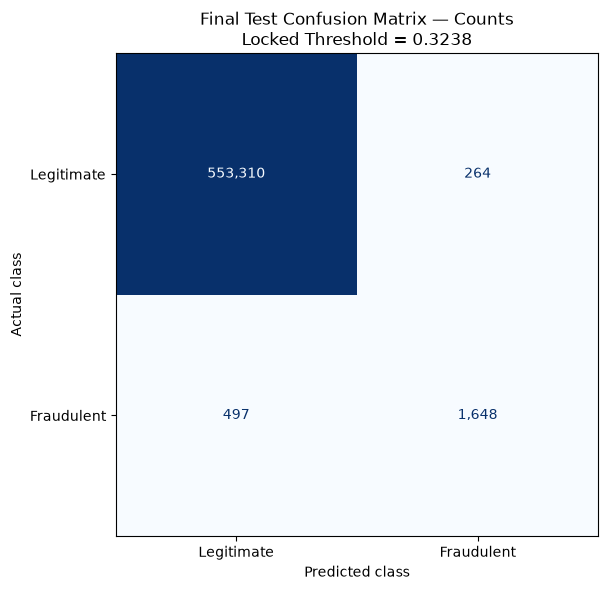

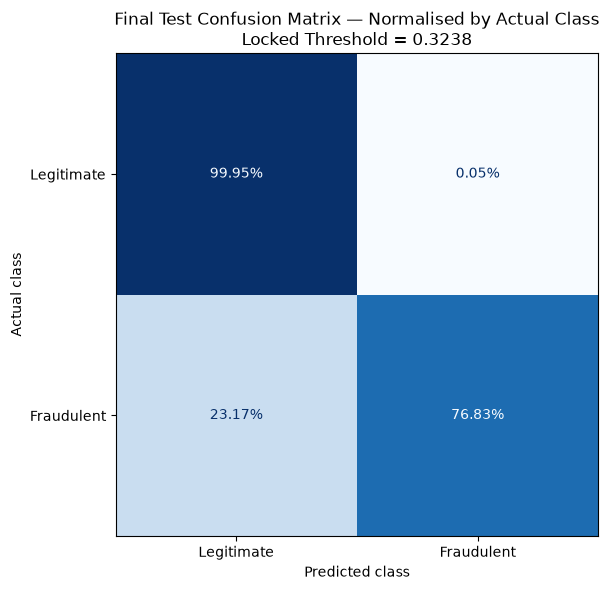

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_class_labels = [
    "Legitimate",
    "Fraudulent"
]

# Raw confusion-matrix counts
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_final_test,
    final_test_predictions,
    display_labels=final_class_labels,
    values_format=",d",
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Final Test Confusion Matrix — Counts\n"
    f"Locked Threshold = {final_classification_threshold:.4f}"
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()


# Row-normalised confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_final_test,
    final_test_predictions,
    display_labels=final_class_labels,
    normalize="true",
    values_format=".2%",
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Final Test Confusion Matrix — Normalised by Actual Class\n"
    f"Locked Threshold = {final_classification_threshold:.4f}"
)

ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

## Final Test Precision–Recall Curve

The Precision–Recall curve evaluates the trade-off between fraud precision and fraud recall across all possible classification thresholds.

This visual is particularly informative for an imbalanced fraud-detection problem because it focuses directly on performance for the minority fraud class.

The previously locked classification threshold is marked on the curve. The threshold is shown only for interpretation and is not changed using the final test results.

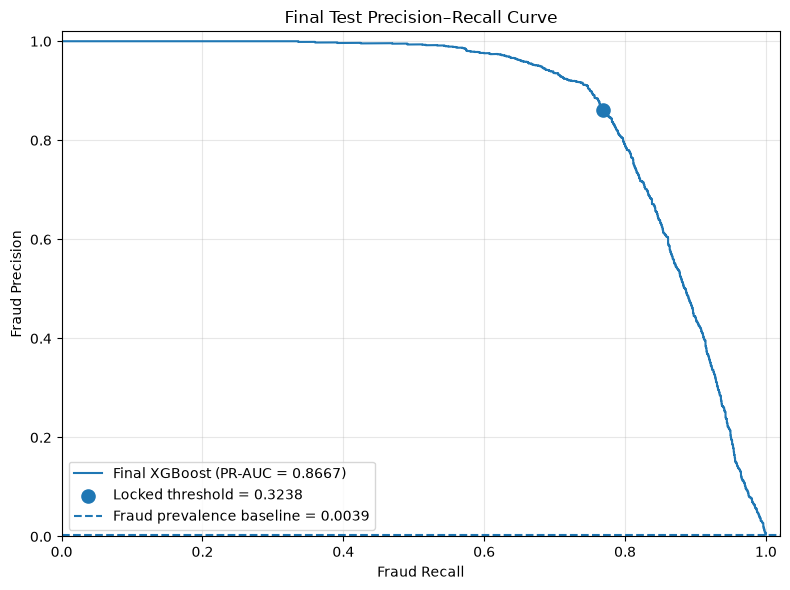

Final test PR-AUC: 0.8667
Precision at locked threshold: 0.8615
Recall at locked threshold: 0.7683


In [109]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import numpy as np

# Calculate precision and recall across all possible thresholds
final_test_precision_curve, final_test_recall_curve, final_test_pr_thresholds = (
    precision_recall_curve(
        y_final_test,
        final_test_probabilities
    )
)

# Calculate PR-AUC using average precision
final_test_pr_auc = average_precision_score(
    y_final_test,
    final_test_probabilities
)

# Find the curve point nearest to the locked classification threshold
nearest_threshold_index = np.argmin(
    np.abs(
        final_test_pr_thresholds
        - final_classification_threshold
    )
)

locked_threshold_precision = (
    final_test_precision_curve[nearest_threshold_index]
)

locked_threshold_recall = (
    final_test_recall_curve[nearest_threshold_index]
)

# Plot the Precision–Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    final_test_recall_curve,
    final_test_precision_curve,
    label=f"Final XGBoost (PR-AUC = {final_test_pr_auc:.4f})"
)

plt.scatter(
    locked_threshold_recall,
    locked_threshold_precision,
    s=90,
    label=(
        f"Locked threshold = "
        f"{final_classification_threshold:.4f}"
    ),
    zorder=5
)

plt.axhline(
    y_final_test.mean(),
    linestyle="--",
    label=(
        f"Fraud prevalence baseline = "
        f"{y_final_test.mean():.4f}"
    )
)

plt.title("Final Test Precision–Recall Curve")
plt.xlabel("Fraud Recall")
plt.ylabel("Fraud Precision")
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Final test PR-AUC:",
    round(final_test_pr_auc, 4)
)

print(
    "Precision at locked threshold:",
    round(locked_threshold_precision, 4)
)

print(
    "Recall at locked threshold:",
    round(locked_threshold_recall, 4)
)

## Final Test ROC Curve

The Receiver Operating Characteristic curve shows the relationship between the true positive rate and the false positive rate across all possible classification thresholds.

The previously locked threshold is marked on the curve for interpretation. It is not adjusted using the final test dataset.

Although ROC-AUC is included as a general measure of class separation, the Precision–Recall curve remains more informative for this highly imbalanced fraud-detection problem.

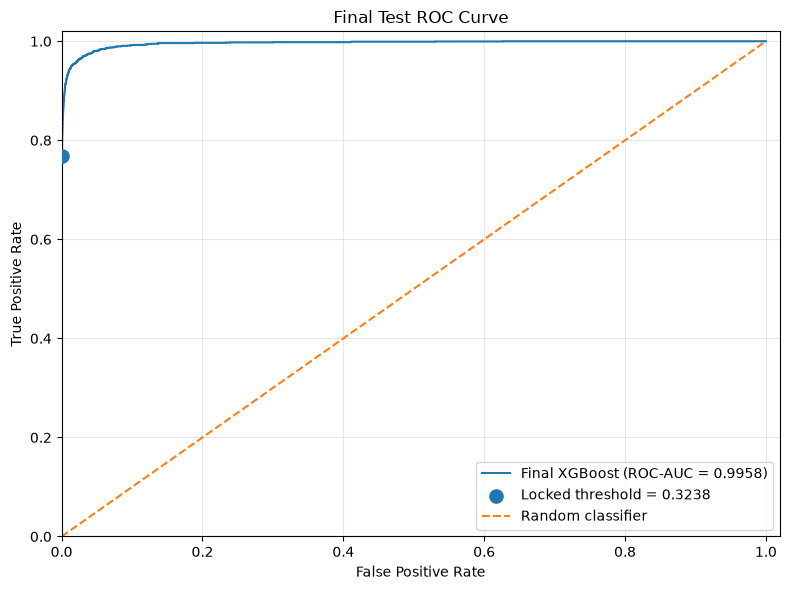

Final test ROC-AUC: 0.9958
False positive rate at locked threshold: 0.000477
True positive rate at locked threshold: 0.7683


In [110]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Calculate ROC curve values
final_test_false_positive_rate, final_test_true_positive_rate, final_test_roc_thresholds = (
    roc_curve(
        y_final_test,
        final_test_probabilities
    )
)

# Calculate ROC-AUC
final_test_roc_auc = roc_auc_score(
    y_final_test,
    final_test_probabilities
)

# Find the ROC point nearest to the locked classification threshold
nearest_roc_threshold_index = np.argmin(
    np.abs(
        final_test_roc_thresholds
        - final_classification_threshold
    )
)

locked_threshold_false_positive_rate = (
    final_test_false_positive_rate[
        nearest_roc_threshold_index
    ]
)

locked_threshold_true_positive_rate = (
    final_test_true_positive_rate[
        nearest_roc_threshold_index
    ]
)

# Plot the ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    final_test_false_positive_rate,
    final_test_true_positive_rate,
    label=(
        f"Final XGBoost "
        f"(ROC-AUC = {final_test_roc_auc:.4f})"
    )
)

plt.scatter(
    locked_threshold_false_positive_rate,
    locked_threshold_true_positive_rate,
    s=90,
    label=(
        f"Locked threshold = "
        f"{final_classification_threshold:.4f}"
    ),
    zorder=5
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.title("Final Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Final test ROC-AUC:",
    round(final_test_roc_auc, 4)
)

print(
    "False positive rate at locked threshold:",
    round(locked_threshold_false_positive_rate, 6)
)

print(
    "True positive rate at locked threshold:",
    round(locked_threshold_true_positive_rate, 4)
)

## Save the Final Fraud Detection Artefact

The fitted preprocessing pipeline, trained final XGBoost model, locked classification threshold, and predictor metadata are saved together as one deployable artefact.

Saving these components together ensures that future transactions receive the same transformations, feature ordering, model scoring, and threshold-based classification used during final evaluation.

The raw datasets and processed training matrices are not included in the saved artefact.

In [111]:
import joblib
import os

final_artifact_filename = "fraudguard_ml_artifact.joblib"

final_fraud_detection_artifact = {
    "model_name": final_model_name,
    "preprocessor": final_preprocessor,
    "model": final_xgboost_model,
    "classification_threshold": final_classification_threshold,
    "selected_predictors": selected_predictors,
    "numerical_predictors": numerical_predictors,
    "categorical_predictors": categorical_predictors,
    "target_column": target_column,
    "model_parameters": final_model_parameters
}

joblib.dump(
    final_fraud_detection_artifact,
    final_artifact_filename
)

final_artifact_size_mb = (
    os.path.getsize(final_artifact_filename)
    / (1024 ** 2)
)

print("Final artefact saved successfully.")
print("Filename:", final_artifact_filename)
print(
    "File size:",
    round(final_artifact_size_mb, 2),
    "MB"
)
print(
    "Saved components:",
    list(final_fraud_detection_artifact.keys())
)

Final artefact saved successfully.
Filename: fraudguard_ml_artifact.joblib
File size: 0.41 MB
Saved components: ['model_name', 'preprocessor', 'model', 'classification_threshold', 'selected_predictors', 'numerical_predictors', 'categorical_predictors', 'target_column', 'model_parameters']


## Verify the Saved Deployment Artefact

The saved fraud-detection artefact is reloaded from disk to verify that it contains all required components and can independently generate predictions.

A small sample from the untouched final test predictors is passed through the reloaded preprocessor and model. The resulting probabilities and classifications are compared with the predictions previously produced in the notebook.

This verification checks that serialization has preserved the fitted preprocessing pipeline, trained model, predictor ordering, and locked classification threshold.

In [112]:
import joblib
import numpy as np
import pandas as pd

# Reload the saved artefact from disk
loaded_fraudguard_artifact = joblib.load(
    final_artifact_filename
)

# Extract the saved components
loaded_preprocessor = loaded_fraudguard_artifact[
    "preprocessor"
]

loaded_model = loaded_fraudguard_artifact[
    "model"
]

loaded_threshold = loaded_fraudguard_artifact[
    "classification_threshold"
]

loaded_predictors = loaded_fraudguard_artifact[
    "selected_predictors"
]

# Use a small sample from the final test predictors
verification_sample_size = 10

verification_sample = X_final_test[
    loaded_predictors
].head(verification_sample_size).copy()

# Apply the reloaded preprocessing pipeline
verification_sample_processed = (
    loaded_preprocessor.transform(
        verification_sample
    )
)

# Generate probabilities using the reloaded model
loaded_sample_probabilities = (
    loaded_model.predict_proba(
        verification_sample_processed
    )[:, 1]
)

# Apply the saved classification threshold
loaded_sample_predictions = (
    loaded_sample_probabilities
    >= loaded_threshold
).astype(int)

# Retrieve the original notebook predictions for comparison
original_sample_probabilities = (
    final_test_probabilities[
        :verification_sample_size
    ]
)

original_sample_predictions = (
    final_test_predictions[
        :verification_sample_size
    ]
)

# Compare the original and reloaded outputs
probabilities_match = np.allclose(
    loaded_sample_probabilities,
    original_sample_probabilities
)

predictions_match = np.array_equal(
    loaded_sample_predictions,
    original_sample_predictions
)

verification_results = pd.DataFrame(
    {
        "original_probability": original_sample_probabilities,
        "loaded_probability": loaded_sample_probabilities,
        "original_prediction": original_sample_predictions,
        "loaded_prediction": loaded_sample_predictions
    }
)

print(
    "Artefact loaded successfully:",
    isinstance(
        loaded_fraudguard_artifact,
        dict
    )
)

print(
    "Saved threshold:",
    round(loaded_threshold, 4)
)

print(
    "Saved predictor count:",
    len(loaded_predictors)
)

print(
    "Probability outputs match:",
    probabilities_match
)

print(
    "Classification outputs match:",
    predictions_match
)

display(
    verification_results.round(
        {
            "original_probability": 6,
            "loaded_probability": 6
        }
    )
)

Artefact loaded successfully: True
Saved threshold: 0.3238
Saved predictor count: 12
Probability outputs match: True
Classification outputs match: True


,original_probability,loaded_probability,original_prediction,loaded_prediction
0,0.0001,0.0001,0,0
1,0.0001,0.0001,0,0
2,0.0000,0.0000,0,0
3,0.0000,0.0000,0,0
4,0.0001,0.0001,0,0
5,0.0054,0.0054,0,0
6,0.0000,0.0000,0,0
7,0.0011,0.0011,0,0
8,0.0001,0.0001,0,0
9,0.0001,0.0001,0,0


## Create the Deployment Feature-Engineering Module

The saved model expects the same 12 predictors used during model development, including transaction-time, customer-age, geographical-distance, and transformed-amount features.

A separate Python module is created to reproduce these transformations from raw transaction data. Keeping this logic in a reusable module reduces the risk of applying different feature calculations in the notebook and the deployed Streamlit application.

The function returns the predictors in the exact order expected by the saved preprocessing pipeline.

In [113]:
%%writefile fraudguard_features.py

import numpy as np
import pandas as pd


SELECTED_PREDICTORS = [
    "city_pop",
    "customer_age",
    "customer_merchant_distance_km",
    "log_transaction_amount",
    "transaction_hour",
    "transaction_day_of_week",
    "transaction_month",
    "gender",
    "state",
    "category",
    "merchant",
    "job"
]


REQUIRED_RAW_COLUMNS = [
    "trans_date_trans_time",
    "dob",
    "amt",
    "lat",
    "long",
    "merch_lat",
    "merch_long",
    "city_pop",
    "gender",
    "state",
    "category",
    "merchant",
    "job"
]


def prepare_model_predictors(raw_transactions):
    """
    Convert raw transaction records into the predictors expected by
    the FraudGuard ML preprocessing pipeline.

    Parameters
    ----------
    raw_transactions : pandas.DataFrame
        Raw transaction records containing the required input columns.

    Returns
    -------
    pandas.DataFrame
        Engineered predictors in the required model input order.
    """

    if not isinstance(raw_transactions, pd.DataFrame):
        raise TypeError(
            "raw_transactions must be a pandas DataFrame."
        )

    missing_columns = [
        column
        for column in REQUIRED_RAW_COLUMNS
        if column not in raw_transactions.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing required raw columns: "
            + ", ".join(missing_columns)
        )

    engineered = raw_transactions.copy()

    engineered["trans_date_trans_time"] = pd.to_datetime(
        engineered["trans_date_trans_time"],
        errors="raise"
    )

    engineered["dob"] = pd.to_datetime(
        engineered["dob"],
        errors="raise"
    )

    transaction_time = engineered["trans_date_trans_time"]
    date_of_birth = engineered["dob"]

    # Transaction-time features
    engineered["transaction_hour"] = (
        transaction_time.dt.hour
    )

    engineered["transaction_day_of_week"] = (
        transaction_time.dt.dayofweek
    )

    engineered["transaction_month"] = (
        transaction_time.dt.month
    )

    # Customer age at the transaction date
    birthday_not_reached = (
        (transaction_time.dt.month < date_of_birth.dt.month)
        |
        (
            (transaction_time.dt.month == date_of_birth.dt.month)
            &
            (transaction_time.dt.day < date_of_birth.dt.day)
        )
    )

    engineered["customer_age"] = (
        transaction_time.dt.year
        - date_of_birth.dt.year
        - birthday_not_reached.astype(int)
    )

    # Customer-to-merchant Haversine distance
    customer_latitude = np.radians(
        engineered["lat"].astype(float)
    )

    customer_longitude = np.radians(
        engineered["long"].astype(float)
    )

    merchant_latitude = np.radians(
        engineered["merch_lat"].astype(float)
    )

    merchant_longitude = np.radians(
        engineered["merch_long"].astype(float)
    )

    latitude_difference = (
        merchant_latitude - customer_latitude
    )

    longitude_difference = (
        merchant_longitude - customer_longitude
    )

    haversine_value = (
        np.sin(latitude_difference / 2) ** 2
        +
        np.cos(customer_latitude)
        * np.cos(merchant_latitude)
        * np.sin(longitude_difference / 2) ** 2
    )

    haversine_value = np.clip(
        haversine_value,
        0.0,
        1.0
    )

    earth_radius_km = 6371.0

    engineered["customer_merchant_distance_km"] = (
        2
        * earth_radius_km
        * np.arcsin(np.sqrt(haversine_value))
    )

    # Logarithmic transaction-amount transformation
    if (engineered["amt"].astype(float) < 0).any():
        raise ValueError(
            "Transaction amount cannot be negative."
        )

    engineered["log_transaction_amount"] = np.log1p(
        engineered["amt"].astype(float)
    )

    model_predictors = engineered[
        SELECTED_PREDICTORS
    ].copy()

    if model_predictors.isna().any().any():
        invalid_columns = model_predictors.columns[
            model_predictors.isna().any()
        ].tolist()

        raise ValueError(
            "Missing or invalid engineered values in: "
            + ", ".join(invalid_columns)
        )

    return model_predictors

Writing fraudguard_features.py


## Verify Deployment Feature Engineering Against the Notebook

The reusable deployment feature-engineering function is tested against transactions already processed by the notebook.

A sample of raw records from the reserved test dataset is passed through `prepare_model_predictors`. Its output is then compared with the corresponding predictors previously produced by the notebook's original `engineer_features` function.

This verifies:

- exact predictor names and ordering;
- equality of categorical predictor values;
- numerical equivalence of all engineered numerical predictors;
- absence of missing or non-finite values.

The model is not retrained or reevaluated in this step.

In [114]:
import importlib
import numpy as np
import pandas as pd
import fraudguard_features

# Reload the module in case it has been edited during this session
importlib.reload(fraudguard_features)

# Confirm that the module expects the same predictor order as the notebook
module_predictor_order_matches = (
    fraudguard_features.SELECTED_PREDICTORS
    == selected_predictors
)

# Select raw test rows for feature-engineering verification
verification_indices = test_clean.sample(
    n=1000,
    random_state=42
).index

raw_verification_transactions = test_clean.loc[
    verification_indices
].copy()

# Generate predictors using the deployment module
deployment_engineered_predictors = (
    fraudguard_features.prepare_model_predictors(
        raw_verification_transactions
    )
)

# Retrieve the predictors previously engineered by the notebook
notebook_engineered_predictors = test_features.loc[
    verification_indices,
    selected_predictors
].copy()

# Compare numerical predictors using floating-point tolerance
numerical_features_match = np.allclose(
    deployment_engineered_predictors[
        numerical_predictors
    ].to_numpy(dtype=float),
    notebook_engineered_predictors[
        numerical_predictors
    ].to_numpy(dtype=float),
    rtol=1e-10,
    atol=1e-10
)

# Compare categorical predictors exactly
categorical_features_match = (
    deployment_engineered_predictors[
        categorical_predictors
    ].reset_index(drop=True)
    .equals(
        notebook_engineered_predictors[
            categorical_predictors
        ].reset_index(drop=True)
    )
)

# Check output validity
deployment_numeric_values = deployment_engineered_predictors[
    numerical_predictors
].to_numpy(dtype=float)

contains_missing_values = (
    deployment_engineered_predictors
    .isna()
    .any()
    .any()
)

contains_non_finite_numerical_values = (
    not np.isfinite(deployment_numeric_values).all()
)

# Calculate the largest numerical difference for verification
maximum_numerical_difference = np.max(
    np.abs(
        deployment_engineered_predictors[
            numerical_predictors
        ].to_numpy(dtype=float)
        -
        notebook_engineered_predictors[
            numerical_predictors
        ].to_numpy(dtype=float)
    )
)

print(
    "Verification sample size:",
    len(verification_indices)
)

print(
    "Module predictor order matches notebook:",
    module_predictor_order_matches
)

print(
    "Numerical engineered features match:",
    numerical_features_match
)

print(
    "Categorical predictor values match:",
    categorical_features_match
)

print(
    "Maximum numerical difference:",
    maximum_numerical_difference
)

print(
    "Deployment output contains missing values:",
    contains_missing_values
)

print(
    "Deployment output contains non-finite numerical values:",
    contains_non_finite_numerical_values
)

print(
    "Complete feature-engineering verification passed:",
    (
        module_predictor_order_matches
        and numerical_features_match
        and categorical_features_match
        and not contains_missing_values
        and not contains_non_finite_numerical_values
    )
)

Verification sample size: 1000
Module predictor order matches notebook: True
Numerical engineered features match: True
Categorical predictor values match: True
Maximum numerical difference: 0.0
Deployment output contains missing values: False
Deployment output contains non-finite numerical values: False
Complete feature-engineering verification passed: True


## Create the Streamlit Prediction Application

A Streamlit application is created to collect one transaction at a time and generate a fraud-risk prediction using the saved deployment artefact.

The application:

- collects the raw values required for feature engineering;
- reproduces the verified engineered predictors;
- applies the saved preprocessing pipeline;
- generates the XGBoost fraud probability;
- applies the locked classification threshold of 0.3238;
- displays the predicted class and fraud-risk probability.

The application does not retrain the model or modify the classification threshold.

In [115]:
%%writefile app.py

from datetime import date, datetime

import joblib
import pandas as pd
import streamlit as st

from fraudguard_features import prepare_model_predictors


ARTIFACT_PATH = "fraudguard_ml_artifact.joblib"


@st.cache_resource
def load_fraudguard_artifact():
    return joblib.load(ARTIFACT_PATH)


st.set_page_config(
    page_title="FraudGuard ML",
    page_icon="🛡️",
    layout="centered"
)

st.title("🛡️ FraudGuard ML")
st.subheader("Credit Card Transaction Fraud Detection")

st.write(
    "Enter the transaction and customer details below to estimate "
    "the probability that the transaction is fraudulent."
)

try:
    artifact = load_fraudguard_artifact()

    preprocessor = artifact["preprocessor"]
    model = artifact["model"]
    classification_threshold = artifact[
        "classification_threshold"
    ]
    selected_predictors = artifact[
        "selected_predictors"
    ]

except Exception as error:
    st.error(
        "The FraudGuard model artefact could not be loaded."
    )
    st.exception(error)
    st.stop()


with st.form("fraud_prediction_form"):

    st.markdown("### Transaction details")

    transaction_date = st.date_input(
        "Transaction date",
        value=date.today()
    )

    transaction_time = st.time_input(
        "Transaction time",
        value=datetime.now().time().replace(
            second=0,
            microsecond=0
        )
    )

    transaction_amount = st.number_input(
        "Transaction amount",
        min_value=0.0,
        value=50.0,
        step=1.0
    )

    category = st.text_input(
        "Transaction category",
        value="shopping_net"
    )

    merchant = st.text_input(
        "Merchant",
        value="fraud_Test Merchant"
    )

    st.markdown("### Customer details")

    date_of_birth = st.date_input(
        "Customer date of birth",
        value=date(1990, 1, 1),
        min_value=date(1900, 1, 1),
        max_value=date.today()
    )

    gender = st.selectbox(
        "Gender",
        options=["M", "F"]
    )

    state = st.text_input(
        "State code",
        value="CA"
    )

    job = st.text_input(
        "Occupation",
        value="Software engineer"
    )

    city_population = st.number_input(
        "City population",
        min_value=0,
        value=100000,
        step=1000
    )

    st.markdown("### Geographical details")

    customer_latitude = st.number_input(
        "Customer latitude",
        min_value=-90.0,
        max_value=90.0,
        value=34.0522,
        format="%.6f"
    )

    customer_longitude = st.number_input(
        "Customer longitude",
        min_value=-180.0,
        max_value=180.0,
        value=-118.2437,
        format="%.6f"
    )

    merchant_latitude = st.number_input(
        "Merchant latitude",
        min_value=-90.0,
        max_value=90.0,
        value=34.0622,
        format="%.6f"
    )

    merchant_longitude = st.number_input(
        "Merchant longitude",
        min_value=-180.0,
        max_value=180.0,
        value=-118.2537,
        format="%.6f"
    )

    submitted = st.form_submit_button(
        "Analyse transaction"
    )


if submitted:

    try:
        transaction_datetime = datetime.combine(
            transaction_date,
            transaction_time
        )

        raw_transaction = pd.DataFrame(
            [
                {
                    "trans_date_trans_time": transaction_datetime,
                    "dob": date_of_birth,
                    "amt": transaction_amount,
                    "lat": customer_latitude,
                    "long": customer_longitude,
                    "merch_lat": merchant_latitude,
                    "merch_long": merchant_longitude,
                    "city_pop": city_population,
                    "gender": gender,
                    "state": state.strip(),
                    "category": category.strip(),
                    "merchant": merchant.strip(),
                    "job": job.strip()
                }
            ]
        )

        engineered_predictors = prepare_model_predictors(
            raw_transaction
        )

        engineered_predictors = engineered_predictors[
            selected_predictors
        ]

        processed_predictors = preprocessor.transform(
            engineered_predictors
        )

        fraud_probability = float(
            model.predict_proba(
                processed_predictors
            )[0, 1]
        )

        predicted_class = int(
            fraud_probability
            >= classification_threshold
        )

        st.markdown("## Prediction result")

        st.metric(
            "Estimated fraud probability",
            f"{fraud_probability:.2%}"
        )

        st.caption(
            "Classification threshold: "
            f"{classification_threshold:.4f}"
        )

        if predicted_class == 1:
            st.error(
                "Potential fraudulent transaction detected."
            )
        else:
            st.success(
                "Transaction classified as legitimate."
            )

        with st.expander(
            "View engineered model predictors"
        ):
            st.dataframe(
                engineered_predictors,
                use_container_width=True
            )

        st.info(
            "This result is a machine-learning risk estimate "
            "and should not be treated as a final banking decision."
        )

    except Exception as error:
        st.error(
            "The transaction could not be processed."
        )
        st.exception(error)

Writing app.py


## Verify the Streamlit Application and Deployment Pipeline

Before launching the web application, the generated Python files are checked for syntax errors.

A deployment smoke test is then performed using one raw transaction from the reserved test dataset. The test loads the saved artefact from disk, applies the reusable feature-engineering module, transforms the predictors, generates a fraud probability, and applies the locked classification threshold.

This confirms that the files required by Streamlit can work together independently of the notebook's trained objects.

In [116]:
import py_compile
import joblib
import numpy as np

from fraudguard_features import prepare_model_predictors

# ---------------------------------------------------------
# 1. Check Python syntax
# ---------------------------------------------------------

py_compile.compile(
    "fraudguard_features.py",
    doraise=True
)

py_compile.compile(
    "app.py",
    doraise=True
)

print("Python syntax verification passed.")


# ---------------------------------------------------------
# 2. Load the saved deployment artefact
# ---------------------------------------------------------

deployment_artifact = joblib.load(
    "fraudguard_ml_artifact.joblib"
)

deployment_preprocessor = deployment_artifact[
    "preprocessor"
]

deployment_model = deployment_artifact[
    "model"
]

deployment_threshold = deployment_artifact[
    "classification_threshold"
]

deployment_predictors = deployment_artifact[
    "selected_predictors"
]


# ---------------------------------------------------------
# 3. Select one raw transaction for a smoke test
# ---------------------------------------------------------

deployment_test_transaction = test_clean.iloc[
    [0]
].copy()

deployment_actual_class = int(
    deployment_test_transaction[
        target_column
    ].iloc[0]
)


# ---------------------------------------------------------
# 4. Reproduce the complete deployment prediction flow
# ---------------------------------------------------------

deployment_engineered_input = (
    prepare_model_predictors(
        deployment_test_transaction
    )
)

deployment_engineered_input = (
    deployment_engineered_input[
        deployment_predictors
    ]
)

deployment_processed_input = (
    deployment_preprocessor.transform(
        deployment_engineered_input
    )
)

deployment_probability = float(
    deployment_model.predict_proba(
        deployment_processed_input
    )[0, 1]
)

deployment_prediction = int(
    deployment_probability
    >= deployment_threshold
)


# ---------------------------------------------------------
# 5. Compare with the notebook's existing prediction
# ---------------------------------------------------------

expected_probability = float(
    final_test_probabilities[0]
)

expected_prediction = int(
    final_test_predictions[0]
)

probability_matches = np.isclose(
    deployment_probability,
    expected_probability
)

prediction_matches = (
    deployment_prediction
    == expected_prediction
)


print("\nDeployment smoke test completed.")

print(
    "Engineered input shape:",
    deployment_engineered_input.shape
)

print(
    "Processed input shape:",
    deployment_processed_input.shape
)

print(
    "Fraud probability:",
    round(deployment_probability, 6)
)

print(
    "Predicted class:",
    deployment_prediction
)

print(
    "Actual class:",
    deployment_actual_class
)

print(
    "Probability matches notebook:",
    probability_matches
)

print(
    "Prediction matches notebook:",
    prediction_matches
)

print(
    "\nComplete deployment verification passed:",
    probability_matches and prediction_matches
)

Python syntax verification passed.

Deployment smoke test completed.
Engineered input shape: (1, 12)
Processed input shape: (1, 1243)
Fraud probability: 5.4e-05
Predicted class: 0
Actual class: 0
Probability matches notebook: True
Prediction matches notebook: True

Complete deployment verification passed: True


## Create the Deployment Requirements File

A `requirements.txt` file is created to specify the Python libraries required by the Streamlit application.

The package versions are taken from the current verified development environment. Recording these versions helps Streamlit Community Cloud recreate a compatible environment for loading the saved preprocessing pipeline and XGBoost model.

In [117]:
from importlib.metadata import version

required_packages = {
    "streamlit": "streamlit",
    "pandas": "pandas",
    "numpy": "numpy",
    "scikit-learn": "scikit-learn",
    "xgboost": "xgboost",
    "joblib": "joblib"
}

requirements_lines = []

for requirement_name, installed_package_name in required_packages.items():
    installed_version = version(installed_package_name)

    requirements_lines.append(
        f"{requirement_name}=={installed_version}"
    )

with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as requirements_file:
    requirements_file.write(
        "\n".join(requirements_lines) + "\n"
    )

print("requirements.txt created successfully.\n")

with open(
    "requirements.txt",
    "r",
    encoding="utf-8"
) as requirements_file:
    print(requirements_file.read())

requirements.txt created successfully.

streamlit==1.58.0
pandas==3.0.3
numpy==2.5.0
scikit-learn==1.9.0
xgboost==3.3.0
joblib==1.5.3



## Verify Local Streamlit Application Startup

The Streamlit application is started temporarily in headless mode to confirm that the deployment files and installed dependencies work together.

The test checks whether Streamlit can:

- load `app.py`;
- import the feature-engineering module;
- load the saved model artefact;
- start the web server without an immediate application error.

The temporary server is stopped automatically after the startup check.

In [118]:
import subprocess
import sys
import time
import urllib.request

streamlit_test_port = 8502

streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.headless=true",
        f"--server.port={streamlit_test_port}",
        "--browser.gatherUsageStats=false"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

streamlit_started_successfully = False
streamlit_response_status = None
startup_error = None

try:
    # Allow time for Streamlit and the saved artefact to load
    for _ in range(20):
        time.sleep(1)

        if streamlit_process.poll() is not None:
            break

        try:
            with urllib.request.urlopen(
                f"http://localhost:{streamlit_test_port}",
                timeout=2
            ) as response:
                streamlit_response_status = response.status

                if response.status == 200:
                    streamlit_started_successfully = True
                    break

        except Exception:
            pass

finally:
    streamlit_process.terminate()

    try:
        streamlit_process.wait(timeout=10)
    except subprocess.TimeoutExpired:
        streamlit_process.kill()
        streamlit_process.wait()

    streamlit_output = streamlit_process.stdout.read()

print(
    "Streamlit startup successful:",
    streamlit_started_successfully
)

print(
    "Local HTTP response status:",
    streamlit_response_status
)

print("\nStreamlit startup log:")
print(streamlit_output)

print(
    "\nLocal deployment startup verification passed:",
    streamlit_started_successfully
    and streamlit_response_status == 200
)

Streamlit startup successful: True
Local HTTP response status: 200

Streamlit startup log:
2026-07-15 19:48:10.134 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://192.168.1.27:8502
  External URL: http://14.1.78.51:8502



Local deployment startup verification passed: True


## Verify Deployment Predictions for Both Transaction Classes

The deployment pipeline is tested with one legitimate transaction and one fraudulent transaction from the reserved test dataset.

Each raw transaction is processed using the standalone feature-engineering module, saved preprocessor, trained XGBoost model, and locked classification threshold.

The resulting probabilities and classifications are compared with the predictions already generated during final test evaluation. This confirms that the deployment workflow behaves consistently for examples from both target classes.

This step does not retrain the model or change the threshold.

In [119]:
import joblib
import numpy as np
import pandas as pd

from fraudguard_features import prepare_model_predictors


# Load the saved deployment artefact
deployment_artifact = joblib.load(
    "fraudguard_ml_artifact.joblib"
)

deployment_preprocessor = deployment_artifact[
    "preprocessor"
]

deployment_model = deployment_artifact[
    "model"
]

deployment_threshold = deployment_artifact[
    "classification_threshold"
]

deployment_predictors = deployment_artifact[
    "selected_predictors"
]


# Find one legitimate and one fraudulent transaction
legitimate_position = np.flatnonzero(
    y_final_test.to_numpy() == 0
)[0]

fraudulent_position = np.flatnonzero(
    y_final_test.to_numpy() == 1
)[0]

verification_positions = [
    legitimate_position,
    fraudulent_position
]

verification_raw_transactions = test_clean.iloc[
    verification_positions
].copy()


# Reproduce the complete deployment prediction pipeline
verification_engineered_inputs = (
    prepare_model_predictors(
        verification_raw_transactions
    )
)

verification_engineered_inputs = (
    verification_engineered_inputs[
        deployment_predictors
    ]
)

verification_processed_inputs = (
    deployment_preprocessor.transform(
        verification_engineered_inputs
    )
)

deployment_probabilities = (
    deployment_model.predict_proba(
        verification_processed_inputs
    )[:, 1]
)

deployment_predictions = (
    deployment_probabilities
    >= deployment_threshold
).astype(int)


# Retrieve the original notebook outputs
expected_probabilities = final_test_probabilities[
    verification_positions
]

expected_predictions = final_test_predictions[
    verification_positions
]

actual_classes = y_final_test.iloc[
    verification_positions
].to_numpy()


# Compare deployment and notebook outputs
probabilities_match = np.allclose(
    deployment_probabilities,
    expected_probabilities
)

predictions_match = np.array_equal(
    deployment_predictions,
    expected_predictions
)


verification_results = pd.DataFrame(
    {
        "actual_class": actual_classes,
        "deployment_probability": deployment_probabilities,
        "deployment_prediction": deployment_predictions,
        "notebook_probability": expected_probabilities,
        "notebook_prediction": expected_predictions
    },
    index=[
        "Legitimate example",
        "Fraudulent example"
    ]
)


print(
    "Verification transaction count:",
    len(verification_raw_transactions)
)

print(
    "Deployment probabilities match notebook:",
    probabilities_match
)

print(
    "Deployment predictions match notebook:",
    predictions_match
)

print(
    "Both actual classes included:",
    set(actual_classes) == {0, 1}
)

print(
    "\nBoth-class deployment verification passed:",
    (
        probabilities_match
        and predictions_match
        and set(actual_classes) == {0, 1}
    )
)

display(
    verification_results.round(
        {
            "deployment_probability": 6,
            "notebook_probability": 6
        }
    )
)

Verification transaction count: 2
Deployment probabilities match notebook: True
Deployment predictions match notebook: True
Both actual classes included: True

Both-class deployment verification passed: True


,actual_class,deployment_probability,deployment_prediction,notebook_probability,notebook_prediction
Legitimate example,0,0.0001,0,0.0001,0
Fraudulent example,1,0.0035,0,0.0035,0


## Verify Both Deployment Decision Outcomes

The previous verification included both actual classes, but the selected fraudulent transaction was missed by the model and therefore produced a legitimate classification.

To test both application outcomes, this step selects:

- one true negative: an actual legitimate transaction predicted as legitimate;
- one true positive: an actual fraudulent transaction predicted as fraudulent.

Both raw transactions are passed through the complete standalone deployment pipeline. Their outputs are compared with the predictions generated during final notebook evaluation.

This confirms that the deployed workflow can reproduce both the legitimate result and the fraud-alert result.

In [120]:
import joblib
import numpy as np
import pandas as pd

from fraudguard_features import prepare_model_predictors


# Load the saved deployment artefact
deployment_artifact = joblib.load(
    "fraudguard_ml_artifact.joblib"
)

deployment_preprocessor = deployment_artifact[
    "preprocessor"
]

deployment_model = deployment_artifact[
    "model"
]

deployment_threshold = deployment_artifact[
    "classification_threshold"
]

deployment_predictors = deployment_artifact[
    "selected_predictors"
]


# Convert final outputs to NumPy arrays for position-based selection
actual_test_classes = y_final_test.to_numpy()
predicted_test_classes = final_test_predictions


# Find one true negative and one true positive
true_negative_positions = np.flatnonzero(
    (actual_test_classes == 0)
    &
    (predicted_test_classes == 0)
)

true_positive_positions = np.flatnonzero(
    (actual_test_classes == 1)
    &
    (predicted_test_classes == 1)
)

if len(true_negative_positions) == 0:
    raise ValueError(
        "No true-negative transaction was found."
    )

if len(true_positive_positions) == 0:
    raise ValueError(
        "No true-positive transaction was found."
    )

true_negative_position = true_negative_positions[0]
true_positive_position = true_positive_positions[0]

verification_positions = [
    true_negative_position,
    true_positive_position
]


# Retrieve the corresponding raw transactions
verification_raw_transactions = test_clean.iloc[
    verification_positions
].copy()


# Run the complete standalone deployment pipeline
verification_engineered_inputs = (
    prepare_model_predictors(
        verification_raw_transactions
    )
)

verification_engineered_inputs = (
    verification_engineered_inputs[
        deployment_predictors
    ]
)

verification_processed_inputs = (
    deployment_preprocessor.transform(
        verification_engineered_inputs
    )
)

deployment_probabilities = (
    deployment_model.predict_proba(
        verification_processed_inputs
    )[:, 1]
)

deployment_predictions = (
    deployment_probabilities
    >= deployment_threshold
).astype(int)


# Retrieve notebook outputs for comparison
expected_probabilities = final_test_probabilities[
    verification_positions
]

expected_predictions = final_test_predictions[
    verification_positions
]

actual_classes = actual_test_classes[
    verification_positions
]


# Verify deployment consistency
probabilities_match = np.allclose(
    deployment_probabilities,
    expected_probabilities
)

predictions_match = np.array_equal(
    deployment_predictions,
    expected_predictions
)

both_decision_outcomes_present = (
    set(deployment_predictions) == {0, 1}
)

verification_results = pd.DataFrame(
    {
        "actual_class": actual_classes,
        "deployment_probability": deployment_probabilities,
        "deployment_prediction": deployment_predictions,
        "notebook_probability": expected_probabilities,
        "notebook_prediction": expected_predictions
    },
    index=[
        "True negative example",
        "True positive example"
    ]
)


print(
    "Deployment probabilities match notebook:",
    probabilities_match
)

print(
    "Deployment predictions match notebook:",
    predictions_match
)

print(
    "Both deployment outcomes included:",
    both_decision_outcomes_present
)

print(
    "\nComplete decision-outcome verification passed:",
    (
        probabilities_match
        and predictions_match
        and both_decision_outcomes_present
    )
)

display(
    verification_results.round(
        {
            "deployment_probability": 6,
            "notebook_probability": 6
        }
    )
)

Deployment probabilities match notebook: True
Deployment predictions match notebook: True
Both deployment outcomes included: True

Complete decision-outcome verification passed: True


,actual_class,deployment_probability,deployment_prediction,notebook_probability,notebook_prediction
True negative example,0,0.0001,0,0.0001,0
True positive example,1,0.9886,1,0.9886,1


## Inspect Files Required for GitHub and Streamlit Deployment

Before packaging the project, the current working directory is inspected to confirm the exact filenames and locations of the notebook and deployment files.

The deployment requires:

- the completed Jupyter notebook;
- `app.py`;
- `fraudguard_features.py`;
- `fraudguard_ml_artifact.joblib`;
- `requirements.txt`.

This step only inspects the files. It does not copy, rename, delete, or package anything.

In [121]:
from pathlib import Path
import pandas as pd

current_directory = Path.cwd()

required_deployment_files = [
    "app.py",
    "fraudguard_features.py",
    "fraudguard_ml_artifact.joblib",
    "requirements.txt"
]

# Locate notebooks in the current directory
notebook_files = sorted(
    current_directory.glob("*.ipynb")
)

# Check the required deployment files
file_inspection_records = []

for filename in required_deployment_files:
    file_path = current_directory / filename

    file_inspection_records.append(
        {
            "file": filename,
            "exists": file_path.exists(),
            "size_mb": (
                round(
                    file_path.stat().st_size / (1024 ** 2),
                    4
                )
                if file_path.exists()
                else None
            ),
            "absolute_path": (
                str(file_path.resolve())
                if file_path.exists()
                else None
            )
        }
    )

file_inspection_results = pd.DataFrame(
    file_inspection_records
)

print("Current working directory:")
print(current_directory.resolve())

print("\nNotebook files found:")

if notebook_files:
    for notebook_file in notebook_files:
        print(
            "-",
            notebook_file.name,
            f"({notebook_file.stat().st_size / (1024 ** 2):.2f} MB)"
        )
else:
    print("No .ipynb files were found in the current directory.")

print("\nRequired deployment files:")
display(file_inspection_results)

print(
    "\nAll required deployment files exist:",
    file_inspection_results["exists"].all()
)

print(
    "At least one notebook was found:",
    len(notebook_files) > 0
)

Current working directory:
E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\notebooks

Notebook files found:
- fraudguard_ml_development.ipynb (0.73 MB)

Required deployment files:


,file,exists,size_mb,absolute_path
0,app.py,True,0.0056,E:\MSc\COM763 - Advanced Machine Learning\Assi...
1,fraudguard_features.py,True,0.0042,E:\MSc\COM763 - Advanced Machine Learning\Assi...
2,fraudguard_ml_artifact.joblib,True,0.4070,E:\MSc\COM763 - Advanced Machine Learning\Assi...
3,requirements.txt,True,0.0001,E:\MSc\COM763 - Advanced Machine Learning\Assi...



All required deployment files exist: True
At least one notebook was found: True


## Organise the Streamlit Deployment Files

The verified deployment files are copied from the notebook directory into their appropriate project folders.

The Streamlit application and its feature-engineering module are placed in the `app` directory. The saved preprocessing and model artefact is placed in the `models` directory, while `requirements.txt` is placed at the project root.

The development notebook remains in the `notebooks` directory. Files are copied rather than moved so that the verified originals remain available during this organisation step.

In [122]:
from pathlib import Path
import shutil
import pandas as pd

# Current notebook location:
# fraudguard-ml/notebooks
notebooks_directory = Path.cwd()

# Project root:
# fraudguard-ml
project_root = notebooks_directory.parent

app_directory = project_root / "app"
models_directory = project_root / "models"

# Ensure destination folders exist
app_directory.mkdir(parents=True, exist_ok=True)
models_directory.mkdir(parents=True, exist_ok=True)

file_copy_plan = {
    "app.py": app_directory / "app.py",
    "fraudguard_features.py": (
        app_directory / "fraudguard_features.py"
    ),
    "fraudguard_ml_artifact.joblib": (
        models_directory / "fraudguard_ml_artifact.joblib"
    ),
    "requirements.txt": (
        project_root / "requirements.txt"
    )
}

copy_results = []

for source_filename, destination_path in file_copy_plan.items():

    source_path = notebooks_directory / source_filename

    if not source_path.exists():
        raise FileNotFoundError(
            f"Source file was not found: {source_path}"
        )

    shutil.copy2(
        source_path,
        destination_path
    )

    copy_results.append(
        {
            "file": source_filename,
            "copied": destination_path.exists(),
            "destination": str(
                destination_path.resolve()
            ),
            "size_mb": round(
                destination_path.stat().st_size
                / (1024 ** 2),
                4
            )
        }
    )

copy_results_df = pd.DataFrame(copy_results)

print("Project root:")
print(project_root.resolve())

print("\nDeployment files organised:")
display(copy_results_df)

print(
    "\nAll files copied successfully:",
    copy_results_df["copied"].all()
)

print(
    "Notebook remains available:",
    (
        notebooks_directory
        / "fraudguard_ml_development.ipynb"
    ).exists()
)

Project root:
E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml

Deployment files organised:


,file,copied,destination,size_mb
0,app.py,True,E:\MSc\COM763 - Advanced Machine Learning\Assi...,0.0056
1,fraudguard_features.py,True,E:\MSc\COM763 - Advanced Machine Learning\Assi...,0.0042
2,fraudguard_ml_artifact.joblib,True,E:\MSc\COM763 - Advanced Machine Learning\Assi...,0.4070
3,requirements.txt,True,E:\MSc\COM763 - Advanced Machine Learning\Assi...,0.0001



All files copied successfully: True
Notebook remains available: True


## Update the Streamlit Application Artefact Path

The Streamlit application and saved model artefact are stored in separate project folders.

The application file is located in `app`, while the model artefact is located in `models`. The artefact path is therefore updated using the location of `app.py` rather than the current working directory.

This makes model loading reliable both locally and on Streamlit Community Cloud.

In [123]:
from pathlib import Path

app_file_path = project_root / "app" / "app.py"

if not app_file_path.exists():
    raise FileNotFoundError(
        f"Streamlit application was not found: {app_file_path}"
    )

app_code = app_file_path.read_text(
    encoding="utf-8"
)

old_path_configuration = (
    'ARTIFACT_PATH = "fraudguard_ml_artifact.joblib"'
)

new_path_configuration = '''APP_DIRECTORY = Path(__file__).resolve().parent
PROJECT_ROOT = APP_DIRECTORY.parent

ARTIFACT_PATH = (
    PROJECT_ROOT
    / "models"
    / "fraudguard_ml_artifact.joblib"
)'''

if old_path_configuration not in app_code:
    raise ValueError(
        "The expected ARTIFACT_PATH line was not found in app.py."
    )

app_code = app_code.replace(
    "from datetime import date, datetime",
    (
        "from datetime import date, datetime\n"
        "from pathlib import Path"
    ),
    1
)

app_code = app_code.replace(
    old_path_configuration,
    new_path_configuration,
    1
)

app_file_path.write_text(
    app_code,
    encoding="utf-8"
)

print("Streamlit artefact path updated successfully.")
print("Application file:", app_file_path.resolve())
print(
    "Expected artefact location:",
    (
        project_root
        / "models"
        / "fraudguard_ml_artifact.joblib"
    ).resolve()
)

print("\nUpdated path configuration:\n")
print(new_path_configuration)

Streamlit artefact path updated successfully.
Application file: E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\app\app.py
Expected artefact location: E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\models\fraudguard_ml_artifact.joblib

Updated path configuration:

APP_DIRECTORY = Path(__file__).resolve().parent
PROJECT_ROOT = APP_DIRECTORY.parent

ARTIFACT_PATH = (
    PROJECT_ROOT
    / "models"
    / "fraudguard_ml_artifact.joblib"
)


## Verify the Organised Streamlit Project Structure

After moving the deployment files into the `app` and `models` directories, the application is tested again from the project root.

This verification checks that:

- `app/app.py` has valid Python syntax;
- the feature-engineering module can be imported;
- the model artefact can be loaded from the `models` directory;
- Streamlit can start successfully using `app/app.py`;
- the local server returns an HTTP 200 response.

The temporary Streamlit server is stopped automatically after the test.

In [124]:
import py_compile
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

# Confirm expected project paths
project_root = Path.cwd().parent

app_file = project_root / "app" / "app.py"
feature_module_file = (
    project_root
    / "app"
    / "fraudguard_features.py"
)
artifact_file = (
    project_root
    / "models"
    / "fraudguard_ml_artifact.joblib"
)
requirements_file = (
    project_root
    / "requirements.txt"
)

required_paths = [
    app_file,
    feature_module_file,
    artifact_file,
    requirements_file
]

missing_paths = [
    str(path)
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required deployment files:\n"
        + "\n".join(missing_paths)
    )


# ---------------------------------------------------------
# 1. Verify Python syntax
# ---------------------------------------------------------

py_compile.compile(
    str(feature_module_file),
    doraise=True
)

py_compile.compile(
    str(app_file),
    doraise=True
)

print("Python syntax verification passed.")


# ---------------------------------------------------------
# 2. Start Streamlit from the project root
# ---------------------------------------------------------

streamlit_test_port = 8503

streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(app_file),
        "--server.headless=true",
        f"--server.port={streamlit_test_port}",
        "--browser.gatherUsageStats=false"
    ],
    cwd=str(project_root),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

streamlit_started_successfully = False
streamlit_response_status = None

try:
    for _ in range(25):
        time.sleep(1)

        if streamlit_process.poll() is not None:
            break

        try:
            with urllib.request.urlopen(
                f"http://localhost:{streamlit_test_port}",
                timeout=2
            ) as response:

                streamlit_response_status = response.status

                if response.status == 200:
                    streamlit_started_successfully = True
                    break

        except Exception:
            pass

finally:
    streamlit_process.terminate()

    try:
        streamlit_process.wait(timeout=10)

    except subprocess.TimeoutExpired:
        streamlit_process.kill()
        streamlit_process.wait()

    streamlit_output = streamlit_process.stdout.read()


print(
    "\nStreamlit startup successful:",
    streamlit_started_successfully
)

print(
    "Local HTTP response status:",
    streamlit_response_status
)

print(
    "Application path:",
    app_file.resolve()
)

print(
    "Artefact path:",
    artifact_file.resolve()
)

print("\nStreamlit startup log:")
print(streamlit_output)

print(
    "\nOrganised deployment verification passed:",
    (
        streamlit_started_successfully
        and streamlit_response_status == 200
    )
)

Python syntax verification passed.

Streamlit startup successful: True
Local HTTP response status: 200
Application path: E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\app\app.py
Artefact path: E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\models\fraudguard_ml_artifact.joblib

Streamlit startup log:
2026-07-15 20:02:37.855 Uvicorn server started on 0.0.0.0:8503

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8503
  Network URL: http://192.168.1.27:8503
  External URL: http://14.1.78.51:8503



Organised deployment verification passed: True


## Create the Git Ignore Configuration

A `.gitignore` file is created at the project root before the repository is uploaded to GitHub.

The raw training and test datasets are excluded because they are large external data files and are not required by the deployed Streamlit application. Temporary notebook files, Python caches, virtual environments, local IDE settings, and generated outputs are also excluded.

The completed notebook, Streamlit application, feature-engineering module, saved model artefact, and `requirements.txt` remain available for version control.

In [125]:
from pathlib import Path

# Current notebook location: fraudguard-ml/notebooks
notebooks_directory = Path.cwd()
project_root = notebooks_directory.parent

gitignore_path = project_root / ".gitignore"

gitignore_content = """# Raw datasets
data/*.csv
data/*.zip

# Keep the data directory in the repository
!data/.gitkeep

# Generated outputs
outputs/*
!outputs/.gitkeep

# Jupyter temporary files
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Python cache and compiled files
__pycache__/
*.py[cod]
*$py.class

# Virtual environments
.venv/
venv/
env/

# IDE and editor settings
.vscode/
.idea/

# Operating-system files
.DS_Store
Thumbs.db

# Streamlit local configuration and secrets
.streamlit/secrets.toml

# Logs and temporary files
*.log
*.tmp
"""

gitignore_path.write_text(
    gitignore_content,
    encoding="utf-8"
)

# Create placeholders so empty folders can remain in Git
data_directory = project_root / "data"
outputs_directory = project_root / "outputs"

data_directory.mkdir(parents=True, exist_ok=True)
outputs_directory.mkdir(parents=True, exist_ok=True)

(data_directory / ".gitkeep").touch()
(outputs_directory / ".gitkeep").touch()

print(".gitignore created successfully.")
print("Location:", gitignore_path.resolve())

print("\n.gitignore contents:\n")
print(gitignore_path.read_text(encoding="utf-8"))

print(
    "Data directory placeholder exists:",
    (data_directory / ".gitkeep").exists()
)

print(
    "Outputs directory placeholder exists:",
    (outputs_directory / ".gitkeep").exists()
)

.gitignore created successfully.
Location: E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml\.gitignore

.gitignore contents:

# Raw datasets
data/*.csv
data/*.zip

# Keep the data directory in the repository
!data/.gitkeep

# Generated outputs
outputs/*
!outputs/.gitkeep

# Jupyter temporary files
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Python cache and compiled files
__pycache__/
*.py[cod]
*$py.class

# Virtual environments
.venv/
venv/
env/

# IDE and editor settings
.vscode/
.idea/

# Operating-system files
.DS_Store
Thumbs.db

# Streamlit local configuration and secrets
.streamlit/secrets.toml

# Logs and temporary files
*.log
*.tmp

Data directory placeholder exists: True
Outputs directory placeholder exists: True


## Audit the GitHub Repository Contents

The project directory is inspected before creating the GitHub repository.

This check confirms that the required notebook and Streamlit deployment files are present, while large raw datasets and temporary development files are excluded by `.gitignore`.

No Git repository is created and no files are committed in this step.

In [126]:
from pathlib import Path
import subprocess
import pandas as pd

# Current notebook location: fraudguard-ml/notebooks
notebooks_directory = Path.cwd()
project_root = notebooks_directory.parent

required_repository_files = {
    "Streamlit application": project_root / "app" / "app.py",
    "Feature-engineering module": (
        project_root / "app" / "fraudguard_features.py"
    ),
    "Saved model artefact": (
        project_root
        / "models"
        / "fraudguard_ml_artifact.joblib"
    ),
    "Development notebook": (
        project_root
        / "notebooks"
        / "fraudguard_ml_development.ipynb"
    ),
    "Dependency file": project_root / "requirements.txt",
    "Git ignore file": project_root / ".gitignore",
    "Data placeholder": project_root / "data" / ".gitkeep",
    "Outputs placeholder": (
        project_root / "outputs" / ".gitkeep"
    )
}

repository_audit_records = []

for description, file_path in required_repository_files.items():
    repository_audit_records.append(
        {
            "component": description,
            "relative_path": str(
                file_path.relative_to(project_root)
            ),
            "exists": file_path.exists(),
            "size_mb": (
                round(
                    file_path.stat().st_size / (1024 ** 2),
                    4
                )
                if file_path.exists()
                else None
            )
        }
    )

repository_audit = pd.DataFrame(
    repository_audit_records
)

# Check whether raw datasets are present locally
local_dataset_files = sorted(
    list((project_root / "data").glob("*.csv"))
    + list((project_root / "data").glob("*.zip"))
)

# Ask Git which local files would be ignored.
# --no-index allows this check before git init.
ignore_check_results = []

for dataset_path in local_dataset_files:
    result = subprocess.run(
        [
            "git",
            "check-ignore",
            "--no-index",
            str(dataset_path)
        ],
        cwd=str(project_root),
        capture_output=True,
        text=True
    )

    ignore_check_results.append(
        {
            "dataset": dataset_path.name,
            "ignored_by_gitignore": result.returncode == 0
        }
    )

dataset_ignore_audit = pd.DataFrame(
    ignore_check_results
)

print("Project root:")
print(project_root.resolve())

print("\nRequired GitHub repository files:")
display(repository_audit)

print(
    "\nAll required repository files exist:",
    repository_audit["exists"].all()
)

print("\nRaw dataset exclusion check:")

if dataset_ignore_audit.empty:
    print(
        "No CSV or ZIP dataset files were found in the data folder."
    )
else:
    display(dataset_ignore_audit)

    print(
        "All detected raw datasets are ignored:",
        dataset_ignore_audit[
            "ignored_by_gitignore"
        ].all()
    )

Project root:
E:\MSc\COM763 - Advanced Machine Learning\Assignment\fraudguard-ml

Required GitHub repository files:


,component,relative_path,exists,size_mb
0,Streamlit application,app\app.py,True,0.0057
1,Feature-engineering module,app\fraudguard_features.py,True,0.0042
2,Saved model artefact,models\fraudguard_ml_artifact.joblib,True,0.4070
3,Development notebook,notebooks\fraudguard_ml_development.ipynb,True,0.7516
4,Dependency file,requirements.txt,True,0.0001
5,Git ignore file,.gitignore,True,0.0005
6,Data placeholder,data\.gitkeep,True,0.0000
7,Outputs placeholder,outputs\.gitkeep,True,0.0000



All required repository files exist: True

Raw dataset exclusion check:
No CSV or ZIP dataset files were found in the data folder.
